# Klasifikasi Bintang, Galaksi, dan Kuasar dari Data SDSS

## Ringkasan Eksekutif

**Masalah:** Mengklasifikasikan 100.000 objek langit ke dalam tiga kelas (Bintang, Galaksi, Kuasar) berdasarkan karakteristik spektralnya, menggunakan data dari Sloan Digital Sky Survey (SDSS).

**Pendekatan:** Membandingkan tiga algoritma klasifikasi (Logistic Regression, Random Forest, XGBoost) terhadap baseline, dengan proses lengkap mulai dari pembersihan data, seleksi fitur, hingga analisis mendalam terhadap kesalahan model.

**Hasil Kunci:**
- Model terbaik (**Random Forest, tuned**) mencapai **accuracy 98%** dan **F1-macro 97%**, jauh di atas baseline (60%).
- **`redshift`** (pergeseran spektrum akibat jarak objek) terbukti menjadi fitur paling menentukan — model kehilangan lebih dari 40% akurasinya jika fitur ini dihilangkan.
- Ditemukan bahwa 22% data yang awalnya terlihat seperti "error" pada `redshift` ternyata adalah karakteristik normal bintang, bukan kesalahan pengukuran — dibuktikan lewat analisis `groupby` per kelas.
- Analisis mendalam pada kesalahan klasifikasi (`QSO` yang salah diprediksi sebagai `GALAXY`) mengungkap bahwa sepertiga kesalahan terjadi dengan keyakinan model yang **tinggi**, bukan sekadar keraguan di batas antar kelas — temuan yang baru terlihat setelah menganalisis seluruh 282 baris, bukan hanya sampel kecil.

**Skill yang ditunjukkan:** Data cleaning berbasis domain knowledge (bukan hapus otomatis), EDA mendalam, perbandingan multi-model, hyperparameter tuning, penanganan data tidak seimbang, error analysis kuantitatif, dan analisis risiko model untuk pemakaian dunia nyata.

📎 *Notebook lengkap dengan seluruh proses analisis ada di bawah. Untuk ringkasan cepat, lihat bagian [Kesimpulan Umum](#kesimpulan-umum) di akhir dokumen.*

---

# PROBLEM DEFINITION & DATA DESCRIPTION

## 1. Problem Definition

Di luar angkasa terdapat berbagai jenis benda langit. Tiga jenis objek yang paling mendasar adalah:
* **Bintang (*Star*)**: Bola gas panas yang memancarkan cahaya sendiri (contoh: Matahari).
* **Galaksi (*Galaxy*)**: Kumpulan miliaran bintang, gas, dan debu yang terikat oleh gaya gravitasi.
* **Kuasar (*Quasar/QSO*)**: Inti galaksi yang sangat jauh dan sangat terang karena memiliki lubang hitam supermasif di pusatnya.

Para astronom membedakan ketiganya dengan mempelajari cahaya yang dipancarkan. Setiap jenis benda langit memiliki "sidik jari cahaya" yang berbeda, yang dikenal sebagai **karakteristik spektral** (pola warna dan intensitas cahaya suatu objek).

Proyek ini bertujuan untuk **mengklasifikasikan** (mengelompokkan secara otomatis) benda langit ke dalam tiga kelas (`STAR`, `GALAXY`, dan `QSO`) berdasarkan karakteristik spektralnya.

Data yang digunakan berasal dari **SDSS** (*Sloan Digital Sky Survey*), yaitu proyek pemetaan langit skala besar menggunakan teleskop khusus. Dataset ini mencakup **100.000 sampel hasil pengamatan** benda langit. Setiap sampel dicatat dalam **17 fitur prediktor** dan **1 kolom target kelas**.

---

## 2. Data Description

Setiap fitur memiliki **rentang nilai wajar** (batas angka normal secara astronomis). Nilai di luar rentang ini dikategorikan sebagai data yang rusak atau terjadi kesalahan pencatatan (*error*).

### A. Fitur Utama untuk Klasifikasi (Fitur Spektral)

Kelompok fitur ini merupakan variabel paling krusial karena berkaitan langsung dengan sifat fisik dan spektrum cahaya objek.

#### 1. Fotometri
Pengukuran kecerahan (*magnitudo*) objek pada lima pita warna/filter cahaya yang berbeda:

| Fitur | Warna Cahaya | Rentang Wajar |
|---|---|---|
| `u` | Ultraviolet (sinar ungu di luar spektrum kasat mata) | $0 \text{ sampai } 35$ |
| `g` | Hijau (*Green*) | $0 \text{ sampai } 35$ |
| `r` | Merah (*Red*) | $0 \text{ sampai } 35$ |
| `i` | Inframerah dekat (*Near Infrared*) | $0 \text{ sampai } 35$ |
| `z` | Inframerah jauh (*Far Infrared*) | $0 \text{ sampai } 35$ |

> **Catatan Fotometri:**  
> Kecerahan diukur menggunakan skala **magnitudo**. Pengukuran ini bersifat terbalik: **semakin kecil nilainya, semakin terang objeknya**. Nilai di bawah `0` (misalnya `-9999`) menandakan kerusakan data (*corrupted data*).

#### 2. Spektroskopi
Analisis cahaya yang diurai menjadi pola warna secara terperinci:

* **`redshift` (Pergeseran Merah)**: Efek pergeseran gelombang cahaya dari objek yang bergerak menjauhi pengamat. Semakin besar nilai `redshift`, semakin cepat objek menjauh dan semakin jauh jaraknya dari Bumi.  
  * **Rentang Wajar**: $-0,01 \text{ sampai } 7,0$. Nilai jauh di bawah $0$ mengindikasikan *error*.

---

### B. Fitur Pendukung (Non-Spektral)

Kelompok fitur ini berisi informasi **administratif dan teknis pengamatan**, seperti identitas objek, koordinat lokasi di langit, dan catatan proses komputasi teleskop. Fitur-fitur ini **tidak mencerminkan sifat fisik cahaya objek**, sehingga dieliminasi dari proses pemodelan utama untuk mencegah *overfitting*.

#### 1. Identitas dan Lokasi Objek
| Fitur | Penjelasan | Rentang Wajar |
|---|---|---|
| `obj_ID` | Identifikasi unik citra foto objek dalam basis data SDSS | ID acak |
| `spec_obj_ID` | Identifikasi unik untuk analisis spektrum cahaya | Bilangan bulat positif ($> 0$) |
| `alpha` | Posisi horizontal objek di langit (*Right Ascension* / bujur astronomis) | $0^\circ \text{ sampai } 360^\circ$ |
| `delta` | Posisi vertikal objek di langit (*Declination* / lintang astronomis) | $-90^\circ \text{ sampai } 90^\circ$ |

#### 2. Catatan Proses Pengamatan
| Fitur | Penjelasan | Rentang Wajar |
|---|---|---|
| `run_ID` | Nomor sesi pemindaian teleskop | Bilangan bulat positif ($> 0$) |
| `rerun_ID` | Kode versi algoritma pemrosesan citra komputer | Umumnya bernilai tetap (`301`) |
| `cam_col` | Nomor kolom sensor kamera teleskop yang merekam | $1 \text{ sampai } 6$ |
| `field_ID` | Nomor potongan area foto (*frame*) di langit | Bilangan bulat positif ($> 0$) |
| `plate` | Nomor piringan logam pengamatan spektroskopi | Bilangan bulat positif ($> 0$) |
| `MJD` | Tanggal perekaman data dalam format *Modified Julian Date* | $51000 \text{ sampai } 60000$ |
| `fiber_ID` | Nomor kabel serat optik yang menangkap cahaya objek | $1 \text{ sampai } 1000$ |

---

### C. Kolom Target (Variabel Dependen)

* **`class`**: Kategori kelas asli dari objek pengamatan. Terdiri dari 3 kelas unik:
  1. **`STAR`**: Bintang
  2. **`GALAXY`**: Galaksi
  3. **`QSO`**: Kuasar (*Quasar*)

---

## 3. Ringkasan Fitur Pemodelan

Dari total **17 fitur prediktor** yang tersedia dalam dataset, **hanya 6 fitur spektral** yang digunakan sebagai dasar masukan model machine learning:
1. Pita fotometri: `u`, `g`, `r`, `i`, `z`
2. Pergeseran spektroskopi: `redshift`

Sebelas fitur lainnya dieliminasi karena bersifat administratif dan tidak merepresentasikan karakteristik fisik objek.

# DATA COLLECTION

In [87]:
import pandas as pd
import numpy as np

df = pd.read_csv('star_classification.csv')

# PREPROCESSING

## EDA(Exploratory Data Analysis)

**Exploratory Data Analysis (EDA)** merupakan tahap penelusuran awal untuk mengenali struktur, pola sebaran, serta potensi masalah pada data guna memastikan kualitas data sebelum digunakan dalam proses pemodelan *machine learning*.

---

### Langkah-Langkah Pelaksanaan EDA

1. **Pemeriksaan Struktur & Tipe Data**
   * Meninjau dimensi dataset (jumlah baris dan kolom), sampel isi data, serta kesesuaian tipe data (*data types*) pada setiap variabel.

2. **Deteksi *Missing Values* & Data Duplikat**
   * Memeriksa keberadaan data kosong/hilang (*missing values*) dan mengidentifikasi entitas baris yang terduplikat.

3. **Analisis Sebaran Nilai Fitur (Distribusi Numerik)**
   * Mengevaluasi bentuk sebaran data pada setiap fitur numerik menggunakan histogram dan mengukur tingkat kemiringan distribusinya (*skewness*).

4. **Analisis Hubungan Antar-Fitur & Terhadap Target Kelas**
   * Mengukur tingkat keterikatan antar-fitur prediktor (*multicollinearity*) serta korelasinya terhadap variabel target (`class`) menggunakan matriks korelasi dan *scatter plot*.

5. **Identifikasi Nilai Ekstrem (*Outliers*) & Anomali Data**
   * Menguji keberadaan nilai pencilan (*outliers*) serta memeriksa adanya nilai data yang berada di luar batas rentang wajar secara teknis maupun astronomis.

In [88]:
def persentase_masalah(df, mask):
    total_rows = len(df)
    masalah_rows = len(df[mask])
    persentase = (masalah_rows / total_rows) * 100
    print(f'Jumlah baris yang bermasalah: {masalah_rows} dari {total_rows} baris ({persentase:.2f}%)')
    return persentase

In [89]:
df.shape

(100000, 18)

In [90]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

Berdasarkan pemeriksaan awal terhadap dataset, diperoleh informasi struktur data sebagai berikut:
* **Dimensi Data**: Terdiri dari **100.000 baris** dan **18 kolom** (17 fitur prediktor dan 1 kolom target `class`).
* **Kelengkapan Data**: Seluruh kolom memiliki *Non-Null Count* sebesar **100.000**, yang mengindikasikan **tidak terdapat sel kosong/hilang (*missing values*)** dalam dataset.
* **Tipe Data (*Data Types*)**:
  * **17 kolom numerik**: Bertipe `float64` dan `int64`.
  * **1 kolom kategorikal**: Bertipe `object` / teks (kolom target `class`).
* **Catatan Tipe Data Prediktor**:
  * Fitur `obj_ID` dan `spec_obj_ID` tersimpan dalam format numerik `float64` meskipun secara fungsi merupakan nomor identifikasi unik (ID). Hal ini tidak menimbulkan masalah karena kedua fitur tersebut dieliminasi dari proses pemodelan dan tidak merepresentasikan sifat fisik cahaya objek.

In [92]:
num_col = df.select_dtypes(include='number').columns
cat_col = df.select_dtypes(include='object').columns

Kolom dipisahkan menjadi **kolom angka** (`num_col`, 17 kolom) dan **kolom kategori** (`cat_col`, 1 kolom yaitu `class`) agar analisis berikutnya lebih mudah.

In [93]:
print(df.isnull().sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [94]:
print(df.duplicated().sum())

0


Pengecekan *missing value* (data kosong) dan duplikat (baris yang sama persis) sama-sama menghasilkan **0**. Artinya tidak ada sel yang kosong dan tidak ada baris ganda, sehingga tidak perlu pengisian atau penghapusan pada tahap ini.

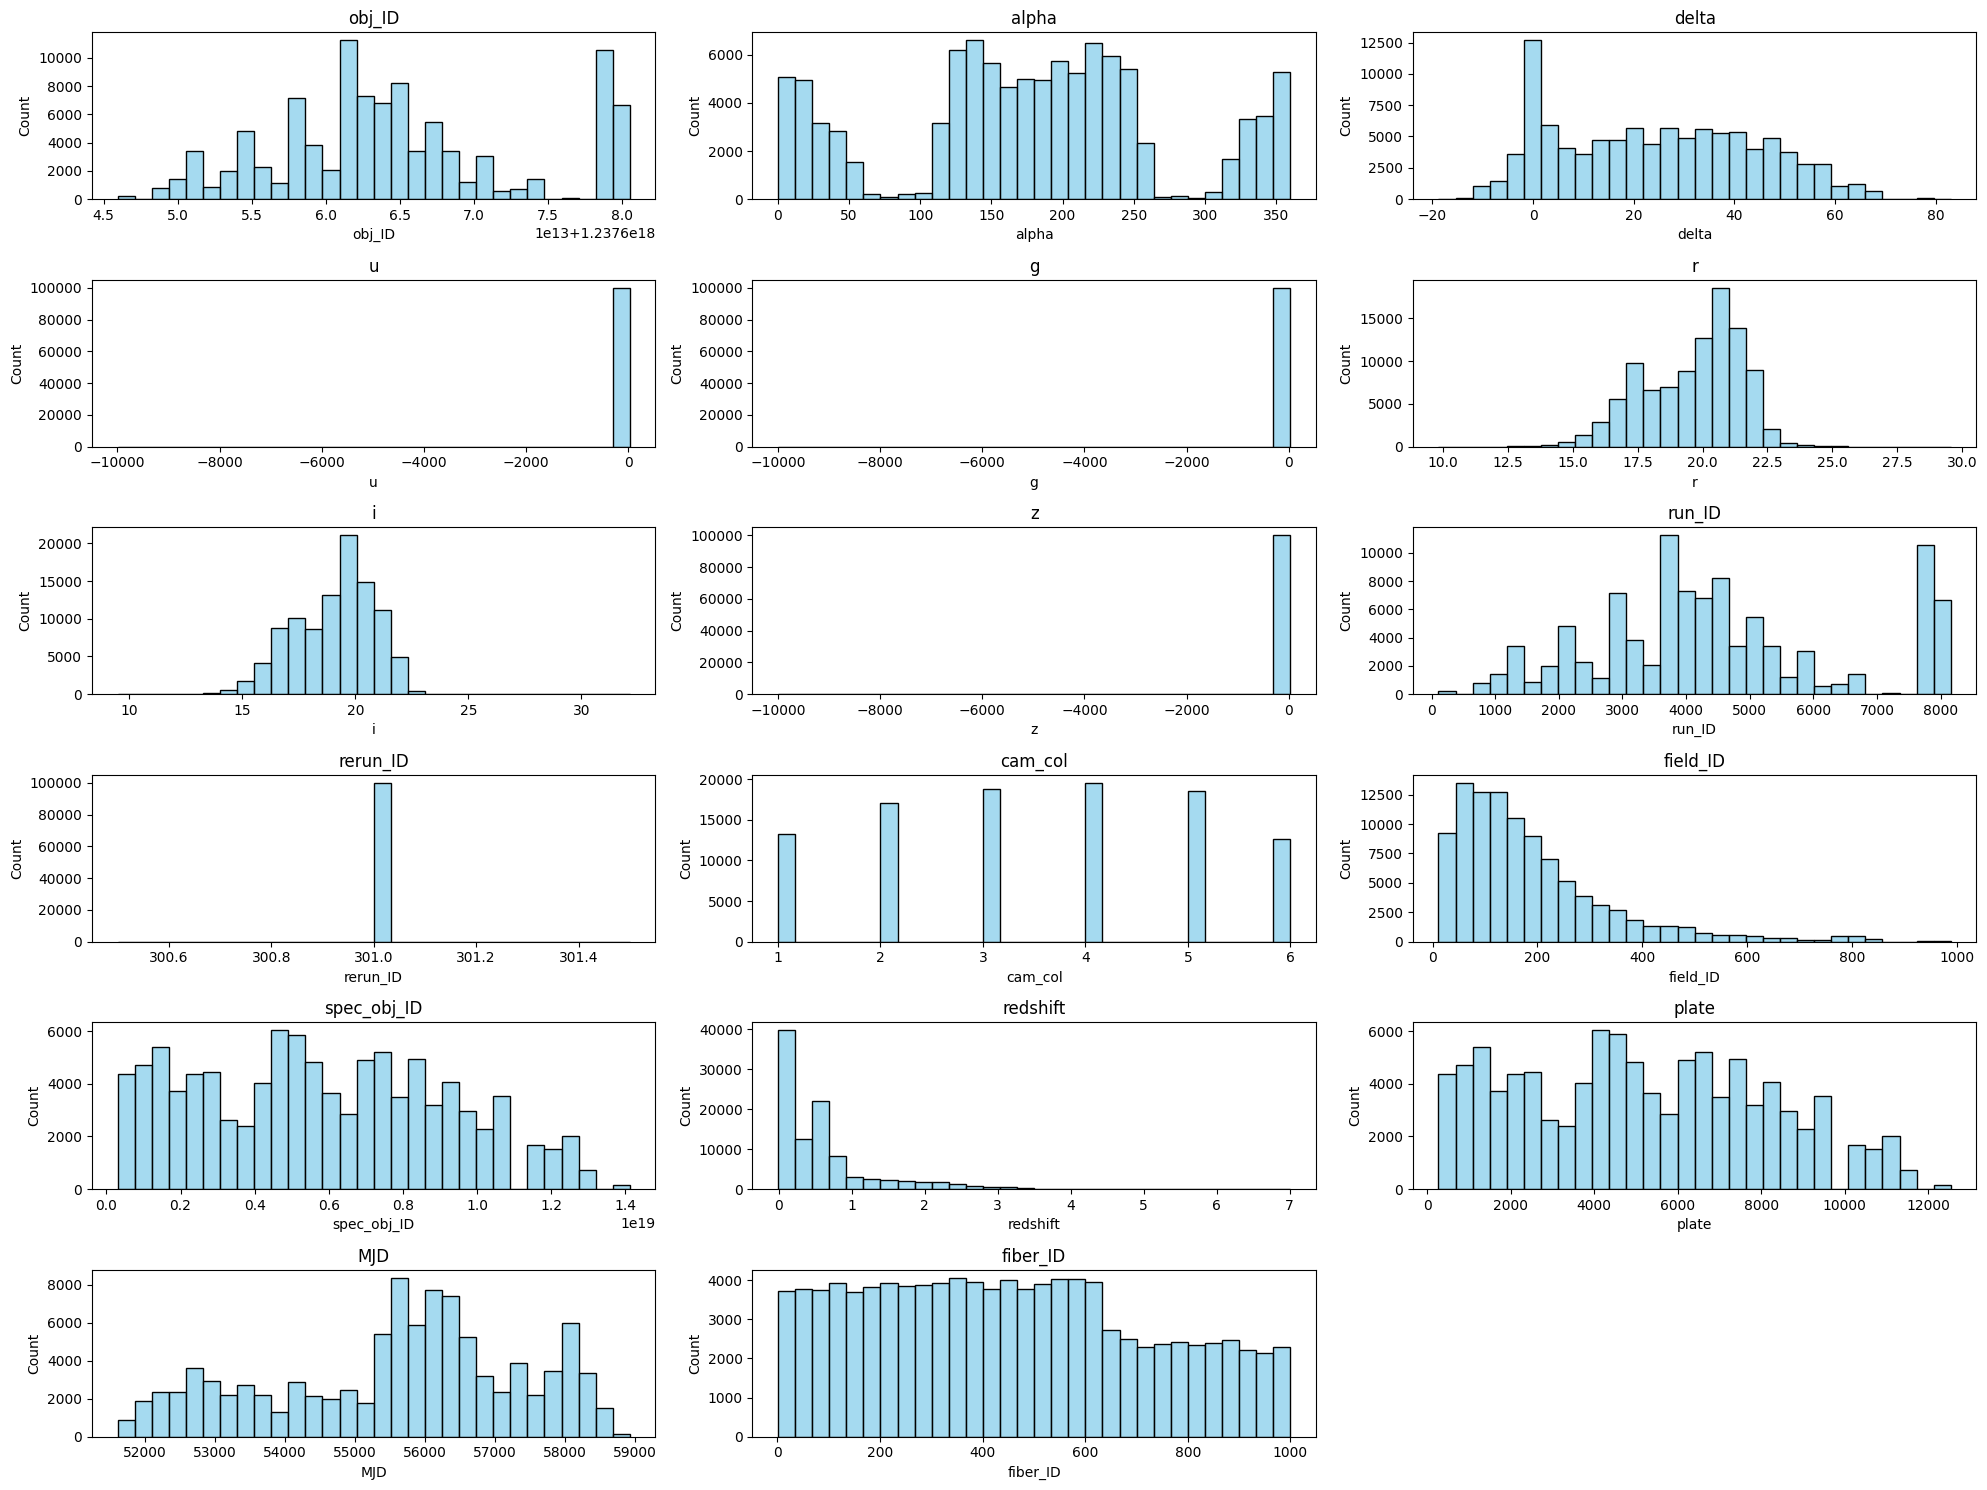

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

n_col = 3
n_row = (len(num_col)//n_col)+1
plt.figure(figsize=(20,15))

for i, col in enumerate(num_col, 1):
    plt.subplot(n_row, n_col, i)
    sns.histplot(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(col)

plt.tight_layout()
plt.show()

Histogram (grafik batang yang menunjukkan seberapa sering suatu nilai muncul) dipakai untuk melihat sebaran tiap fitur. Hasilnya:

- **`u`, `g`, dan `z`**: hanya tampak satu batang di dekat angka 0, sedangkan sumbu bawah membentang sampai -10.000. Ini terjadi karena ada nilai `-9999` (kode untuk data rusak) yang "menarik" grafik ke kiri, sehingga bentuk sebaran aslinya tidak terlihat.
- **`r` dan `i`**: berbentuk lonceng dengan puncak sekitar 20 dan tidak tampak nilai rusak.
- **`redshift`**: sebagian besar nilai menumpuk di dekat 0, dengan ekor panjang ke kanan sampai sekitar 7 (miring ke kanan).
- **`rerun_ID`**: hanya berisi satu nilai (301), sehingga tidak bisa membedakan objek satu dengan yang lain.
- **`cam_col`**: bernilai 1 sampai 6 dengan jumlah yang relatif merata.
- **`alpha`**: ada dua celah dengan data sangat sedikit (sekitar 60 sampai 110 dan 270 sampai 300), kemungkinan karena bagian langit tersebut tidak diamati secara merata.
- **Fitur ID dan teknis lainnya** (`obj_ID`, `run_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`): bentuknya tidak beraturan. Ini wajar karena berupa penomoran atau waktu, bukan sifat cahaya.

In [96]:
skewness = df[num_col].skew()
print("Skewness of numerical columns:")
print(skewness)

Skewness of numerical columns:
obj_ID           0.398727
alpha           -0.028511
delta            0.175079
u             -313.849242
g             -314.276695
r               -0.507858
i               -0.404167
z             -314.759419
run_ID           0.398711
rerun_ID         0.000000
cam_col         -0.030532
field_ID         1.753425
spec_obj_ID      0.198463
redshift         2.523606
plate            0.198472
MJD             -0.381853
fiber_ID         0.229719
dtype: float64


*Skewness* (ukuran kemiringan sebaran; 0 berarti simetris, positif berarti ekor panjang di kanan, negatif berarti ekor panjang di kiri) memperkuat temuan pada histogram:

- `u`, `g`, dan `z` bernilai sekitar **-314**, angka yang sangat ekstrem. Ini bukan sifat asli data, melainkan efek nilai `-9999`.
- `redshift` bernilai **2,52** (miring ke kanan). Ini sesuai histogram karena kebanyakan objek dekat dan hanya sedikit yang sangat jauh.
- `field_ID` bernilai **1,75** (miring ke kanan).
- Fitur lainnya berada di kisaran -0,5 sampai 0,4, artinya sebarannya cukup simetris.

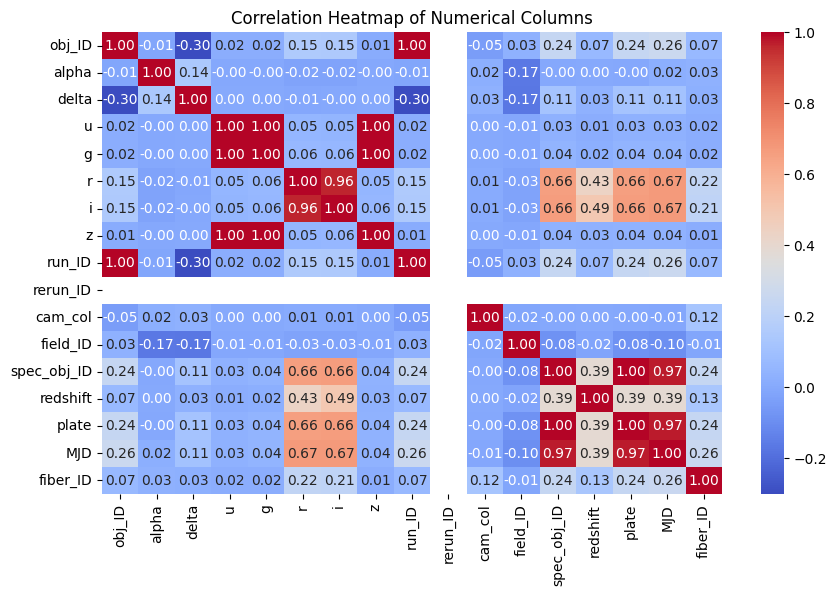

In [97]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

Korelasi (angka -1 sampai 1 yang menunjukkan kuat lemahnya hubungan dua fitur; makin mendekati 1 atau -1 makin kuat) antar fitur menunjukkan:

- **`u`, `g`, dan `z` saling berkorelasi 1,00.** Angka ini kemungkinan semu karena dipengaruhi nilai `-9999` yang sama, sehingga perlu dicek ulang setelah data dibersihkan.
- **`r` dan `i` berkorelasi 0,96**, artinya sangat kuat. Keduanya adalah pita warna yang berdekatan sehingga informasinya mirip.
- **`obj_ID` dan `run_ID` berkorelasi 1,00; `spec_obj_ID` dan `plate` berkorelasi 1,00**; keduanya juga berkorelasi 0,97 dengan `MJD`. Kolom-kolom ini membawa informasi yang berulang (redundan).
- **`rerun_ID` kosong** karena nilainya konstan, sehingga korelasinya tidak bisa dihitung.
- **`redshift`** berkorelasi sedang dengan `r` (0,43) dan `i` (0,49).
- **`r` dan `i` dengan `plate`, `spec_obj_ID`, dan `MJD`** berkorelasi sekitar 0,66 sampai 0,67. Kemungkinan ini terkait cara atau waktu pengamatan, bukan sifat objek, sehingga tidak dijadikan patokan.

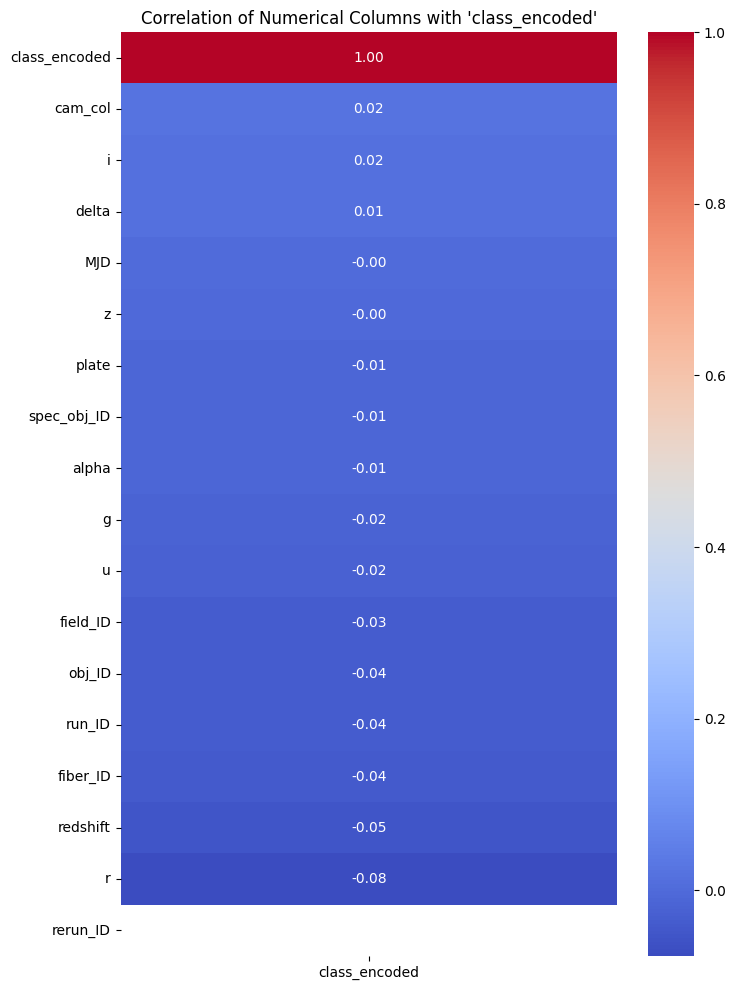

In [98]:
mapping = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
df['class_encoded'] = df['class'].map(mapping)

corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(8, 12))
sns.heatmap(corr[['class_encoded']].sort_values(by='class_encoded', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of Numerical Columns with 'class_encoded'")
plt.show()

Seluruh nilai korelasi terhadap kelas sangat kecil (antara -0,08 sampai 0,02), dan yang terbesar adalah `r` (-0,08). Sekilas seolah tidak ada fitur yang berguna, tetapi hasil ini perlu dibaca hati-hati:

- `class_encoded` hanyalah angka pengganti (GALAXY = 0, QSO = 1, STAR = 2). Urutan angka ini tidak bermakna, sehingga korelasi kurang cocok untuk kelas yang bersifat kategori.
- Korelasi hanya mengukur hubungan garis lurus (linear), sedangkan hubungan fitur dengan kelas bisa berpola lain.
- Nilai `u`, `g`, dan `z` masih terpengaruh `-9999`.

Karena itu, korelasi rendah **tidak berarti** fitur tidak berguna. Pengecekan dilanjutkan dengan *scatter plot*. Kolom `rerun_ID` kosong karena nilainya konstan.

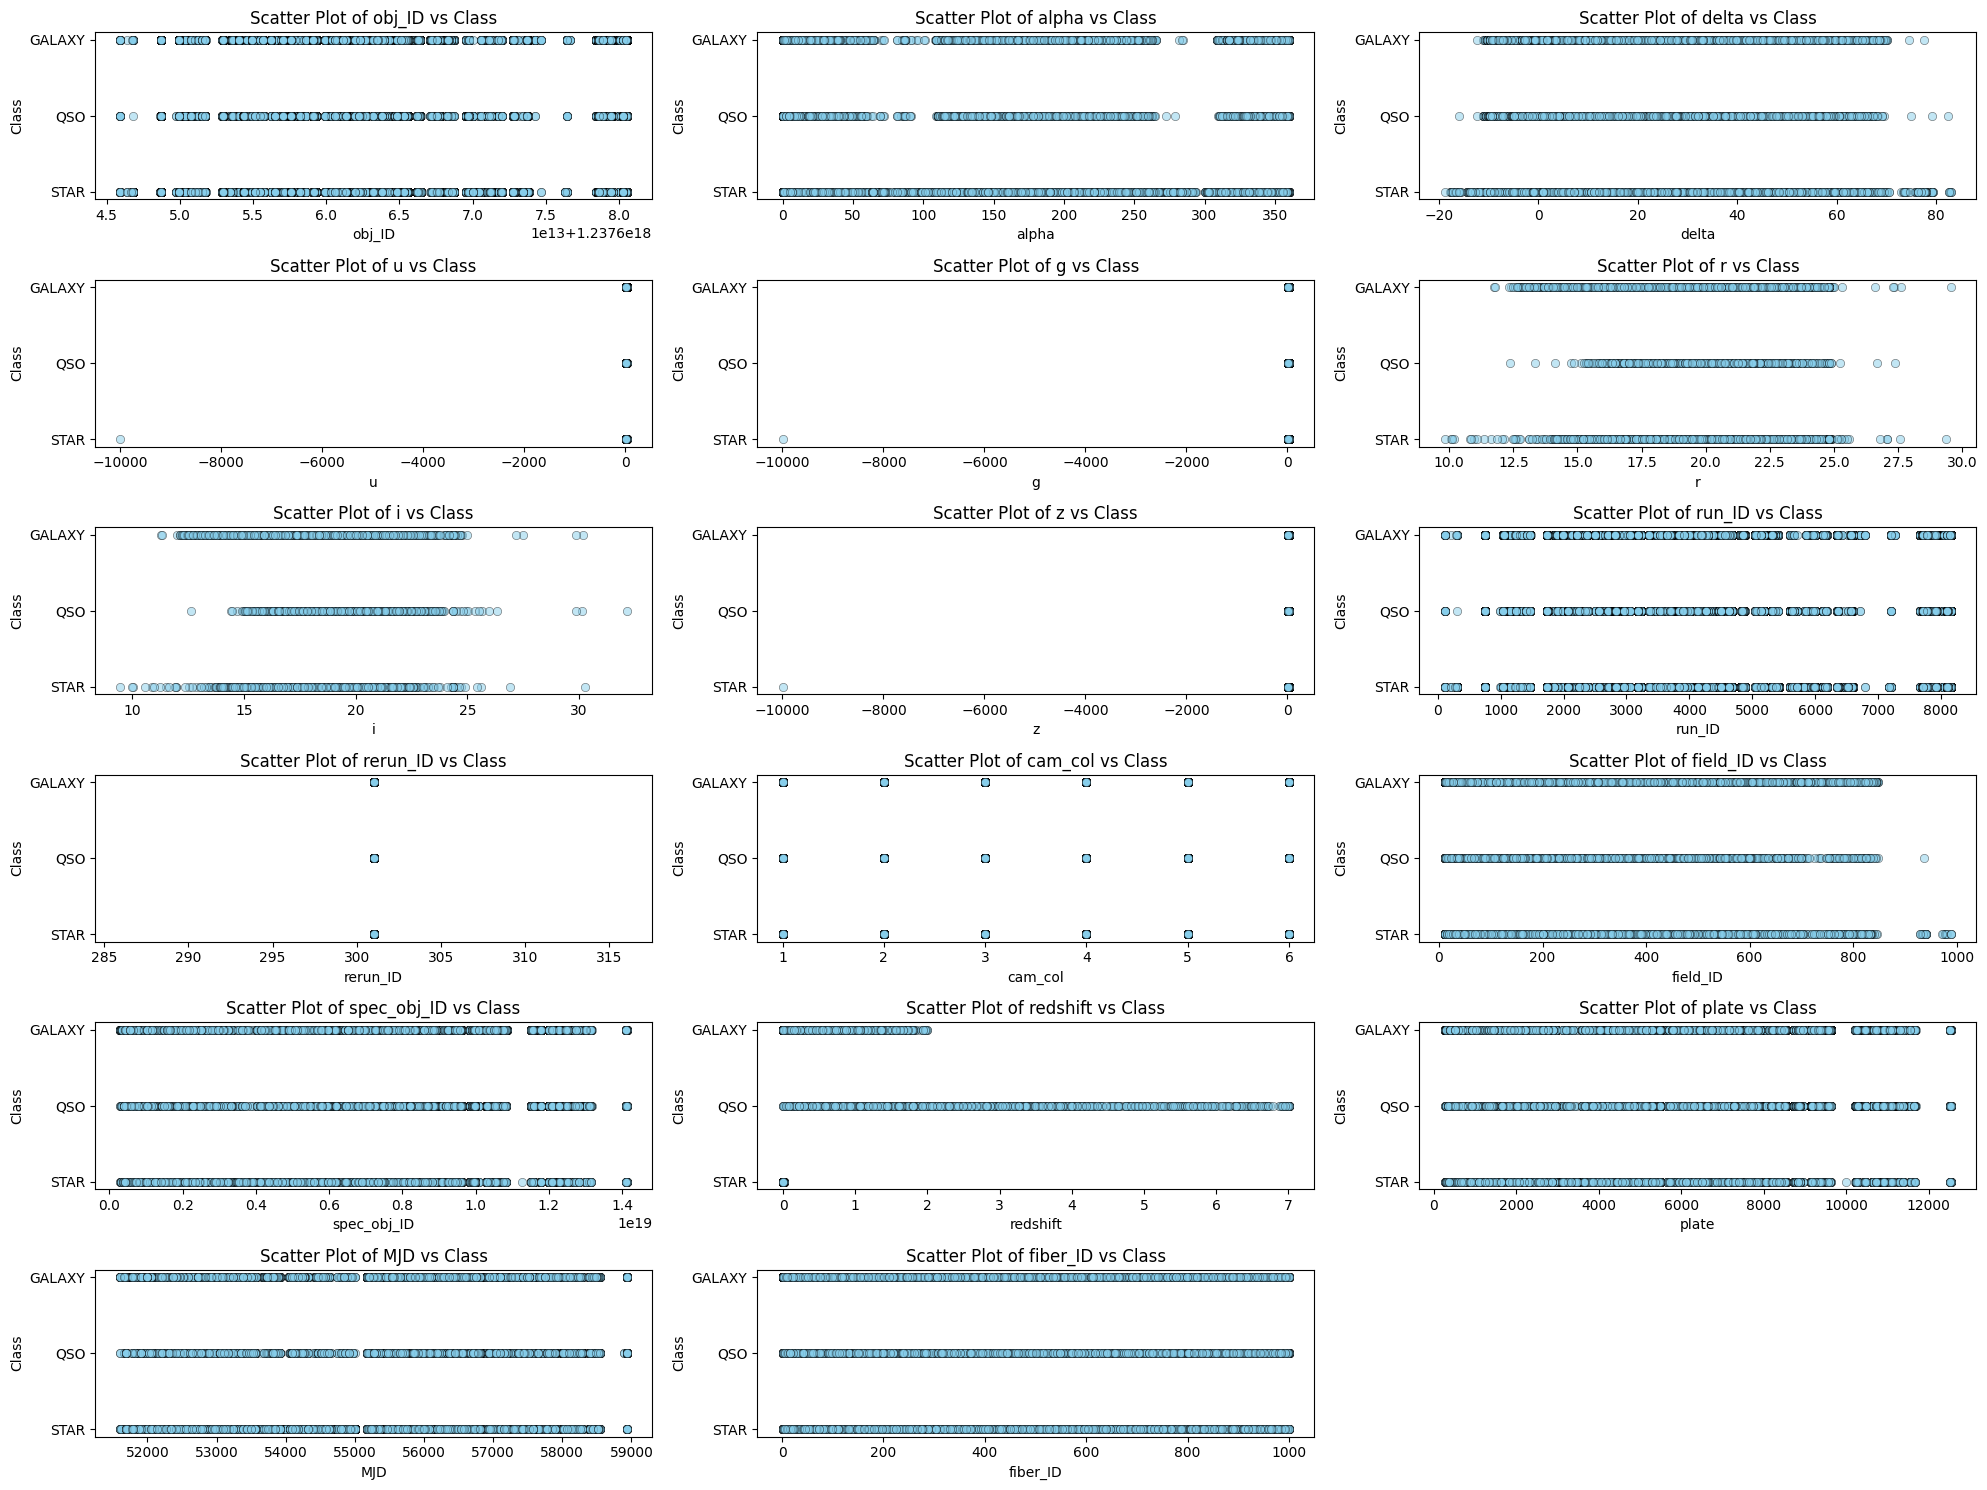

In [99]:
n_col = 3
n_row = (len(num_col)//n_col)+1
plt.figure(figsize=(20,15))

for i, col in enumerate(num_col, 1):
    plt.subplot(n_row, n_col, i)
    sns.scatterplot(x=df[col], y=df['class'], alpha=0.5, color='skyblue', edgecolor='black')
    plt.title(f'Scatter Plot of {col} vs Class')
    plt.xlabel(col)
    plt.ylabel('Class')

plt.tight_layout()
plt.show()

*Scatter plot* (grafik titik) menunjukkan sebaran nilai tiap fitur pada masing-masing kelas:

- **`redshift` adalah fitur yang paling jelas membedakan kelas**: `STAR` berkumpul di sekitar 0, `GALAXY` mencapai sekitar 2, dan `QSO` menjangkau sampai sekitar 7.
- **`r` dan `i`**: `STAR` mencapai nilai lebih kecil (sekitar 10, artinya lebih terang) dibanding `GALAXY` (mulai sekitar 12) dan `QSO` (sebagian besar mulai sekitar 14 sampai 15). Namun tumpang tindihnya besar, sehingga kedua fitur ini hanya membantu sebagian.
- **`u`, `g`, dan `z`**: tampak satu titik `STAR` di sekitar -10.000. Ini menunjukkan nilai rusak kemungkinan berasal dari satu objek yang sama.
- **Fitur lain** (ID, posisi, dan teknis): sebaran ketiga kelas hampir sama, sehingga tidak membantu membedakan kelas.

In [100]:
q1 = df[num_col].quantile(0.25)
q3 = df[num_col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
mask = (df[num_col] < lower_bound) | (df[num_col] > upper_bound)
print(mask.sum().sort_values(ascending=False))

redshift       8990
field_ID       5391
z               320
i               198
r               132
g                99
u                56
obj_ID            0
MJD               0
plate             0
spec_obj_ID       0
run_ID            0
cam_col           0
rerun_ID          0
alpha             0
delta             0
fiber_ID          0
dtype: int64


Metode IQR menganggap suatu nilai ekstrem jika berada di bawah Q1 - 1,5×IQR atau di atas Q3 + 1,5×IQR (Q1 adalah batas 25% data terendah, dan IQR adalah selisih Q3 dan Q1, yaitu rentang 50% data tengah). Hasilnya: `redshift` 8.990 baris (8,99%), `field_ID` 5.391 baris, `z` 320 baris, `i` 198 baris, `r` 132 baris, `g` 99 baris, dan `u` 56 baris. Fitur lainnya tidak memiliki nilai ekstrem.

Nilai-nilai ini **tidak dihapus**, dengan alasan:
- **`redshift`**: nilai tinggi berasal dari objek yang memang sangat jauh (galaksi jauh dan kuasar). Ini nilai asli, dan menghapusnya justru menghilangkan data kelas `QSO`.
- **`field_ID`**: hanya nomor potongan area foto, bukan sifat cahaya.
- **`u`, `g`, `z`, `i`, `r`**: jumlahnya kecil (kurang dari 0,4%) dan selain `-9999`, nilai maksimumnya masih di bawah 35 sehingga tergolong objek yang sangat redup atau sangat terang, bukan kesalahan.

Satu-satunya nilai yang dianggap rusak adalah `-9999`.

In [101]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID,class_encoded
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740,0.621490
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404,0.816778
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000,0.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000,0.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000,0.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000,1.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000,2.000000


Ringkasan statistik (*mean* = rata-rata, *std* = seberapa jauh data menyebar dari rata-rata, *min* dan *max* = nilai terkecil dan terbesar) menunjukkan:

- **`u`, `g`, dan `z` memiliki nilai minimum -9999**, padahal rentang wajarnya 0 sampai 35. Akibatnya `std` ketiganya sekitar 31,7, jauh lebih besar daripada `r` dan `i` (sekitar 1,8) yang seharusnya sama-sama kecil. Nilai maksimumnya (32,78; 31,60; dan 29,38) masih wajar.
- **`redshift`** memiliki nilai minimum -0,00997, yang masih berada dalam batas wajar (tidak kurang dari -0,01), sehingga **bukan** kesalahan. Nilai maksimum 7,01 hanya sedikit di atas 7,0, dan ini masih wajar untuk kuasar karena batas 7,0 hanyalah perkiraan.
- **Fitur lainnya sesuai rentang wajar**: `alpha` (0 sampai 360), `delta` (-18,8 sampai 83), `cam_col` (1 sampai 6), `fiber_ID` (1 sampai 1000), dan `MJD` (51.608 sampai 58.932).
- **`rerun_ID`** selalu bernilai 301 dengan `std` 0.

In [102]:
print((df['redshift'] < 0.01).sum())
print(df[df['redshift'] < 0.01]['class'].value_counts())
df.groupby('class')['redshift'].describe()

22202
STAR      21594
GALAXY      603
QSO           5
Name: class, dtype: int64


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,59445.0,0.421596,0.264858,-0.009971,0.164527,0.456274,0.594699,1.995524
QSO,18961.0,1.719676,0.913954,0.000461,1.106605,1.617232,2.220279,7.011245
STAR,21594.0,-0.000115,0.000465,-0.004136,-0.000295,-0.000076,0.000075,0.004153


Terdapat 22.201 baris dengan `redshift` sangat kecil (< 0,01). Untuk memastikan ini bukan kesalahan pengukuran, dilakukan analisis `groupby` (pengelompokan data) per kelas. Hasilnya, 97,26% baris tersebut berasal dari kelas `STAR` (seluruh bintang berada di kelompok ini), sedangkan sisanya 2,72% `GALAXY` dan 0,02% `QSO`.

Hal ini sejalan dengan konsep astronomi: bintang berada relatif dekat di dalam galaksi kita sendiri sehingga tidak mengalami pergeseran warna (*redshift*) yang berarti, berbeda dengan galaksi dan kuasar yang jauh di luar galaksi kita. Karena itu nilai kecil ini **valid dan tidak dihapus**.

### Kesimpulan EDA

Temuan utama:
1. Data tidak memiliki nilai kosong maupun duplikat.
2. Masalah utama adalah nilai `-9999` pada `u`, `g`, dan `z`, yang merusak `mean`, `std`, *skewness*, dan korelasi.
3. `redshift` yang mendekati nol dan nilai ekstrem `redshift` adalah nilai asli, sehingga dipertahankan.
4. `rerun_ID` bernilai tetap (301), sehingga tidak informatif.
5. Beberapa kolom saling berulang: `obj_ID` dengan `run_ID`, `spec_obj_ID` dengan `plate` dan `MJD`, serta `r` dengan `i`.
6. `redshift` adalah fitur yang paling jelas membedakan kelas, sedangkan `r` dan `i` membantu sebagian.

Langkah selanjutnya adalah membersihkan nilai `-9999`, membuang kolom yang tidak informatif atau berulang, dan memilih fitur yang akan dipakai untuk pemodelan.

## Data Cleaning

Tahap ini membersihkan masalah yang ditemukan pada EDA. Ada dua temuan yang diperiksa:

1. Nilai `-9999` pada fitur `u`, `g`, dan `z`.
2. Nilai `redshift` yang sangat kecil (< 0,01) pada sekitar 22% baris.

Setiap temuan diperiksa dulu sebelum diputuskan: dihapus, diperbaiki dengan imputasi (mengisi nilai rusak dengan perkiraan, misalnya rata-rata), atau dibiarkan.

In [103]:
mask1 = df[['u', 'g', 'z']] < 0
persentase_masalah(df, mask1.any(axis=1))

Jumlah baris yang bermasalah: 1 dari 100000 baris (0.00%)


0.001

In [104]:
df_clean = df[~mask1.any(axis=1)]

Pengecekan nilai negatif pada `u`, `g`, dan `z` menemukan **hanya 1 baris** dari 100.000 (0,001%; tertulis 0,00% pada output karena pembulatan). Karena hanya satu baris yang bermasalah, ketiga nilai `-9999` tadi berasal dari baris yang sama.

Nilai `-9999` adalah *sentinel value* (angka penanda yang sengaja dipakai sistem untuk menandai bahwa pengukuran gagal). Magnitudo tidak mungkin sekecil itu, sehingga ini murni kegagalan alat, bukan data asli.

**Keputusan:** baris tersebut **dihapus**, bukan diimputasi. Jumlahnya sangat kecil (0,001%) sehingga penghapusan tidak berpengaruh pada data, sedangkan mengisinya dengan perkiraan justru memasukkan angka yang tidak sebenarnya. Data bersih (`df_clean`) berjumlah **99.999 baris**.

In [105]:
mask2 = df_clean[['redshift']] < 0.01
mask_row = mask2.any(axis=1)
persentase_masalah(df_clean, mask_row)

Jumlah baris yang bermasalah: 22201 dari 99999 baris (22.20%)


22.20122201222012

Nilai `redshift` di bawah 0,01 ditemukan pada **22.201 baris (22,20%)**. Angka ini terlalu besar untuk disebut kerusakan data (sekitar satu dari lima baris), sehingga perlu diperiksa lebih dalam: apakah nilai tersebut milik kelas tertentu?

In [106]:
print("Distribusi redshift < 0.01:")
print(df_clean[mask_row]['class'].value_counts(normalize=True), "\n")
print("Distribusi kelas:")
print(df_clean['class'].value_counts(normalize=True))

Distribusi redshift < 0.01:
STAR      0.972614
GALAXY    0.027161
QSO       0.000225
Name: class, dtype: float64 

Distribusi kelas:
GALAXY    0.594456
STAR      0.215932
QSO       0.189612
Name: class, dtype: float64


Dari baris dengan `redshift` < 0,01, sebanyak **97,26% berkelas `STAR`**, 2,72% `GALAXY`, dan 0,02% `QSO`. Bandingkan dengan komposisi seluruh data: `GALAXY` 59,45%, `STAR` 21,59%, dan `QSO` 18,96%. Artinya `redshift` kecil sangat khas milik bintang, padahal bintang hanya sekitar seperlima dari seluruh data.

Galaksi di kelompok ini (sekitar 600 baris) kemungkinan letaknya dekat dengan kita sehingga pergeseran warnanya juga kecil. Ada pula 5 kuasar di kelompok ini; jumlahnya sangat kecil sehingga tetap dipertahankan.

In [107]:
df_clean.groupby('class')['redshift'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,59445.0,0.421596,0.264858,-0.009971,0.164527,0.456274,0.594699,1.995524
QSO,18961.0,1.719676,0.913954,0.000461,1.106605,1.617232,2.220279,7.011245
STAR,21593.0,-0.000115,0.000465,-0.004136,-0.000295,-0.000076,0.000075,0.004153


Ringkasan `redshift` per kelas (*count* = jumlah data, *mean* = rata-rata, *std* = seberapa jauh data menyebar dari rata-rata, *min* dan *max* = nilai terkecil dan terbesar):

| Kelas | Jumlah | Mean | Std | Min | Max |
|-------|--------|------|-----|-----|-----|
| `GALAXY` | 59.445 | 0,42 | 0,26 | -0,00997 | 2,00 |
| `QSO` | 18.961 | 1,72 | 0,91 | 0,00046 | 7,01 |
| `STAR` | 21.593 | -0,0001 | 0,0005 | -0,00414 | 0,00415 |

- **`STAR`**: seluruh nilainya berada di sekitar nol. Bintang berada di dalam galaksi kita sehingga tidak mengalami pergeseran warna yang berarti. Nilai negatif yang sangat kecil wajar karena sebagian bintang bergerak mendekati kita.
- **`GALAXY`**: rata-rata 0,42 dengan nilai tertinggi sekitar 2.
- **`QSO`**: paling jauh, rata-rata 1,72 dan mencapai 7.

Ketiga kelas memiliki rentang `redshift` yang berbeda, sehingga fitur ini sangat informatif. Jika nilai kecil dihapus, hampir seluruh data `STAR` ikut hilang.

In [108]:
print(df_clean[df_clean['redshift'] < -0.01])
print(df_clean[(df_clean['class'] == 'STAR') & (df_clean['redshift'].abs() > 0.01)])

Empty DataFrame
Columns: [obj_ID, alpha, delta, u, g, r, i, z, run_ID, rerun_ID, cam_col, field_ID, spec_obj_ID, class, redshift, plate, MJD, fiber_ID, class_encoded]
Index: []
Empty DataFrame
Columns: [obj_ID, alpha, delta, u, g, r, i, z, run_ID, rerun_ID, cam_col, field_ID, spec_obj_ID, class, redshift, plate, MJD, fiber_ID, class_encoded]
Index: []


Kedua pengecekan menghasilkan *DataFrame* kosong (tabel tanpa baris), artinya:

- tidak ada `redshift` di bawah -0,01 (batas wajar), dan
- tidak ada bintang dengan `redshift` di luar ±0,01.

Tidak ditemukan tanda kesalahan pengukuran maupun kesalahan label pada `redshift`. **Keputusan:** fitur ini tidak dihapus dan tidak diimputasi.

Ambang < 0,01 yang dipakai di awal ternyata kurang tepat untuk fitur ini karena sebaran `redshift` bergantung pada kelasnya. Nilai `-9999` dan `redshift` kecil ditangani berbeda karena penyebabnya berbeda: yang pertama adalah kegagalan alat, yang kedua adalah informasi asli yang berguna.

### Kesimpulan Data Cleaning

| Temuan | Penyebab | Keputusan |
|--------|----------|-----------|
| `-9999` pada `u`, `g`, `z` (1 baris) | Kegagalan pengukuran | Baris dihapus |
| `redshift` < 0,01 (22,20% baris) | Nilai asli, 97,26% milik `STAR` | Dipertahankan |

Data bersih berjumlah **99.999 baris**.

## Split Data

Dari 17 fitur, dipilih **6 fitur** untuk pemodelan: `u`, `g`, `r`, `i`, `z`, dan `redshift`. Variabel `x` berisi 6 fitur ini (bahan untuk memprediksi), sedangkan `y` berisi kolom `class` (jawaban yang ingin diprediksi).

Alasan pemilihan:
- Keenam fitur ini adalah fitur spektral, sesuai tujuan proyek.
- 11 fitur lainnya berupa identitas dan catatan teknis pengamatan. Pada EDA, sebarannya hampir sama untuk ketiga kelas sehingga tidak membantu membedakan kelas.
- Sebagian fitur berulang (`obj_ID` dengan `run_ID`; `spec_obj_ID` dengan `plate` dan `MJD`), dan `rerun_ID` bernilai tetap 301.
- Fitur ID dan teknis dapat membuat model "menghafal" kondisi pengamatan, bukan mempelajari sifat cahaya objek.

In [109]:
main_df = df_clean[['u','g','r','i','z','redshift','class']].copy()

x = main_df.drop('class', axis=1)
y = main_df['class']

### Pemeriksaan Ulang Data Setelah Cleaning

Setelah pembersihan dan pemilihan fitur, grafik dan statistik diulang pada 6 fitur terpilih. Tujuannya memastikan masalah `-9999` benar-benar hilang dan melihat pola yang sebelumnya tertutup nilai rusak.

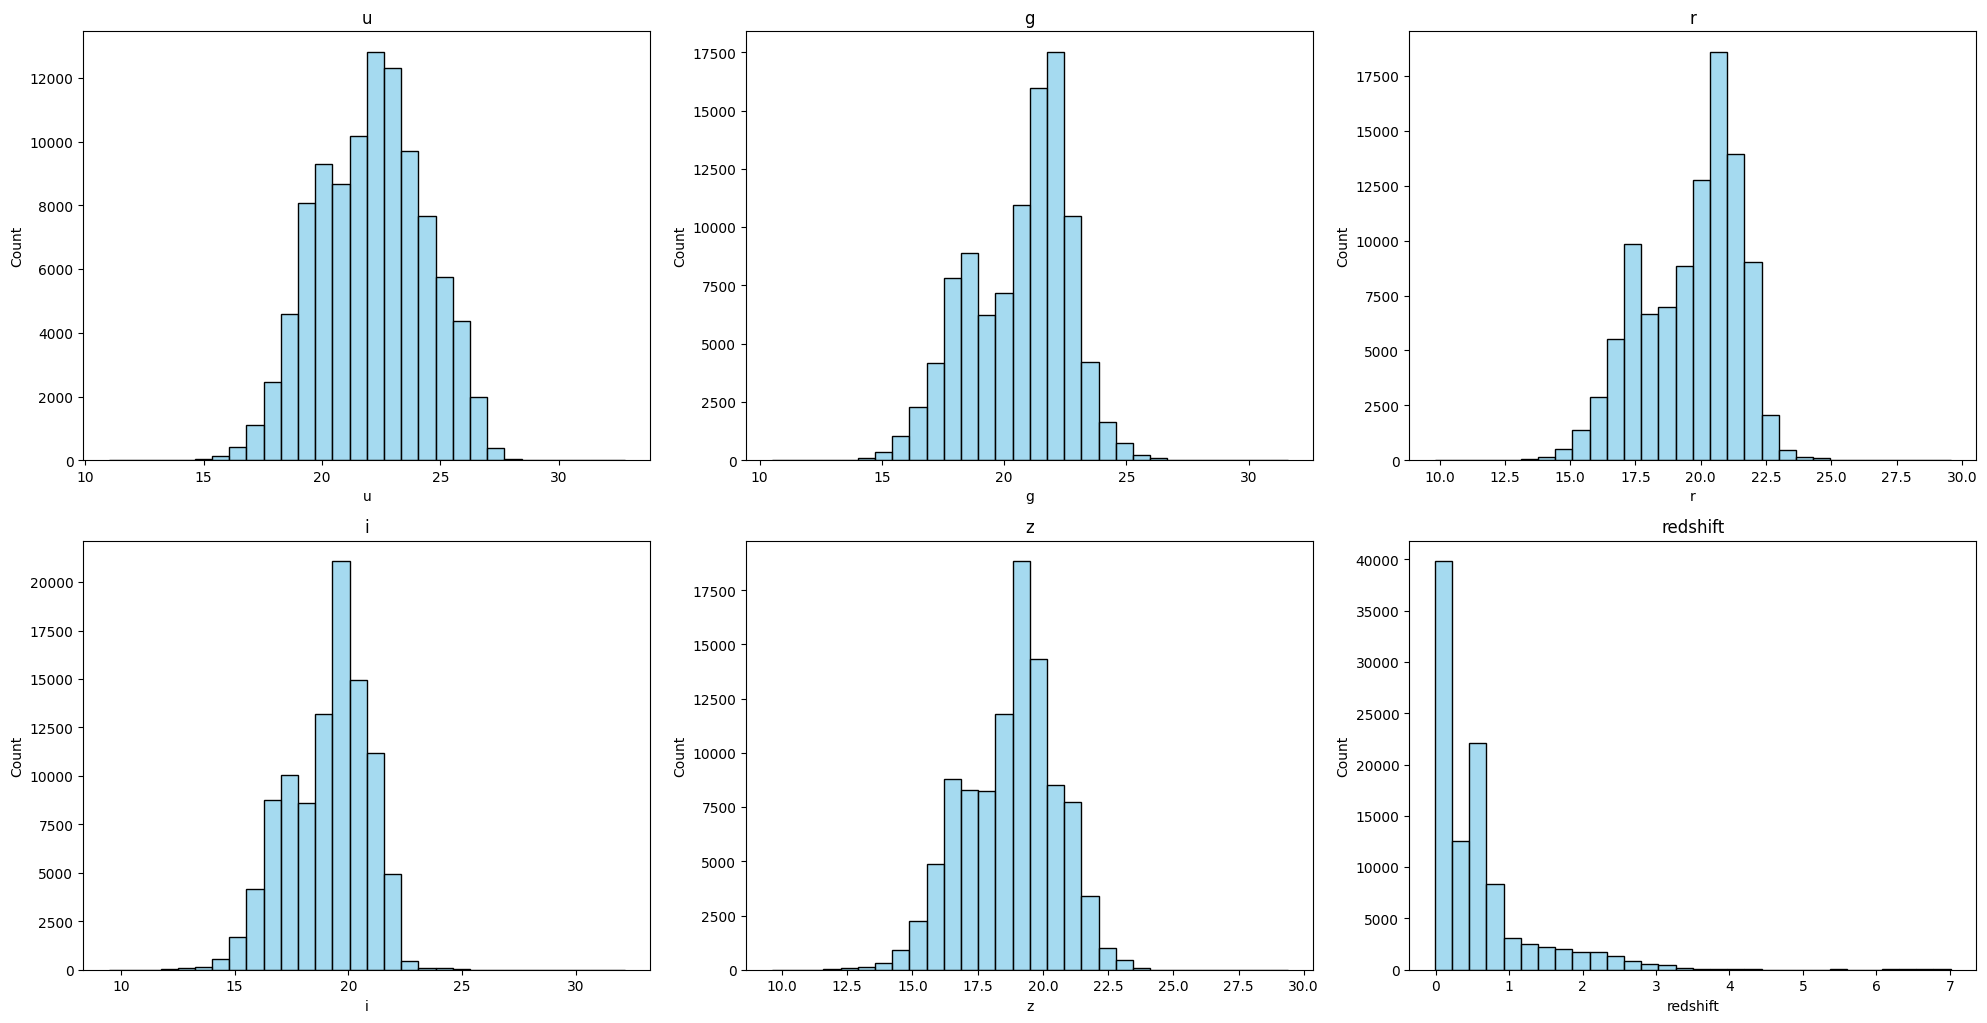

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns


num_col = main_df.select_dtypes(include='number').columns
n_col = 3
n_row = (len(num_col)//n_col)+1
plt.figure(figsize=(20,15))

for i, col in enumerate(num_col, 1):
    plt.subplot(n_row, n_col, i)
    sns.histplot(main_df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(col)

plt.tight_layout()
plt.show()

Histogram `u`, `g`, dan `z` kini terlihat normal dan tidak lagi menumpuk di satu batang:

- **`u`**: berbentuk lonceng, puncak sekitar 22 sampai 23.
- **`g`**: puncak sekitar 21 sampai 22, dengan puncak kecil di sekitar 18 sampai 19.
- **`r`**: dua puncak, di sekitar 17,5 dan 20,5.
- **`i`**: puncak tajam di sekitar 20.
- **`z`**: puncak sekitar 19 sampai 20, dengan puncak kecil di sekitar 16,5 sampai 18.
- **`redshift`**: menumpuk di dekat 0 (sekitar 40.000 data), puncak kedua di sekitar 0,5, lalu ekor panjang sampai 7.

Adanya lebih dari satu puncak pada `g`, `r`, `i`, dan `z` kemungkinan menandakan data berasal dari kelompok objek yang berbeda (bintang, galaksi, kuasar) dengan tingkat kecerahan berbeda.

In [111]:
skewness = main_df[num_col].skew()
print("Skewness of numerical columns:")
print(skewness)

Skewness of numerical columns:
u          -0.070298
g          -0.428037
r          -0.507880
i          -0.404183
z          -0.256822
redshift    2.523599
dtype: float64


*Skewness* (ukuran kemiringan sebaran; 0 berarti simetris) setelah cleaning:

| Fitur | `u` | `g` | `r` | `i` | `z` | `redshift` |
|-------|-----|-----|-----|-----|-----|------------|
| Skewness | -0,07 | -0,43 | -0,51 | -0,40 | -0,26 | 2,52 |

- Nilai sekitar **-314** pada `u`, `g`, dan `z` sudah hilang. Ini membuktikan bahwa penyebabnya memang satu baris `-9999`.
- Kelima pita warna kini cukup simetris (miring ringan ke kiri).
- `redshift` tetap miring kuat ke kanan (2,52). Ini bukan kesalahan data, melainkan sifat aslinya: kebanyakan objek dekat dan hanya sedikit yang sangat jauh. Fitur ini dibiarkan apa adanya.

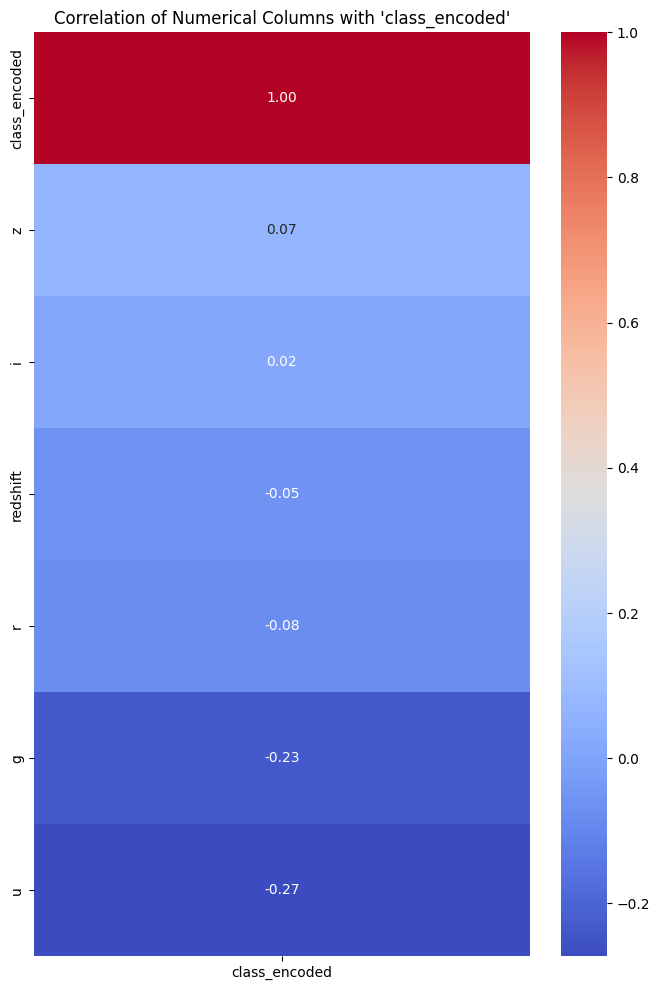

In [112]:
mapping = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
main_df['class_encoded'] = main_df['class'].map(mapping)

corr = main_df.select_dtypes(include='number').corr()
plt.figure(figsize=(8, 12))
sns.heatmap(corr[['class_encoded']].sort_values(by='class_encoded', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of Numerical Columns with 'class_encoded'")
plt.show()

Korelasi tiap fitur dengan `class_encoded` (GALAXY = 0, QSO = 1, STAR = 2): `u` -0,27, `g` -0,23, `r` -0,08, `redshift` -0,05, `i` 0,02, dan `z` 0,07.

Pada EDA, korelasi `u` dan `g` hanya -0,02. Setelah satu baris `-9999` dihapus, korelasinya naik tajam. Jadi **satu baris rusak saja dapat menyembunyikan hubungan yang sebenarnya**.

Meski begitu, semua nilai masih kecil, dan tidak boleh disimpulkan bahwa fitur lain tidak berguna. Angka 0, 1, 2 hanyalah pengganti nama kelas, dan korelasi hanya mengukur hubungan garis lurus. `redshift` contohnya: `STAR` (2) mendekati nol, `QSO` (1) tinggi, `GALAXY` (0) sedang. Pola ini tidak berupa garis lurus sehingga korelasinya kecil, padahal pada scatter plot fitur ini membedakan kelas dengan jelas.

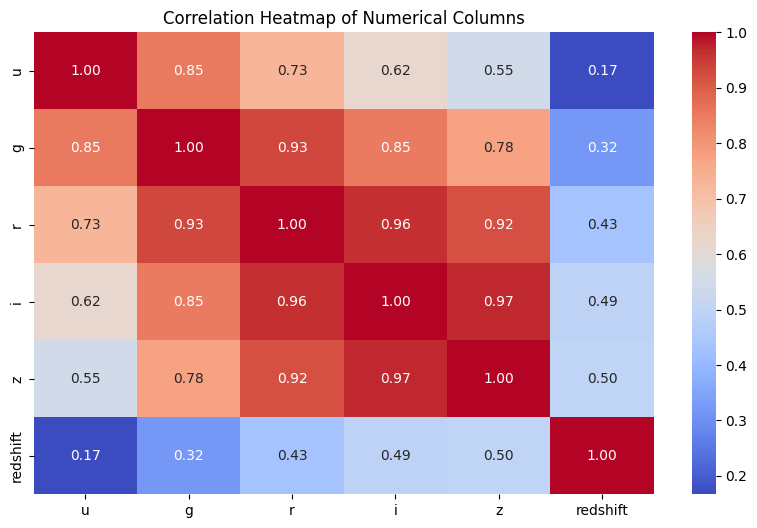

In [113]:
plt.figure(figsize=(10, 6))
sns.heatmap(main_df[num_col].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

Korelasi antar fitur (angka -1 sampai 1; makin mendekati 1, makin kuat hubungannya):

- **Antar pita warna semuanya positif dan kuat**, dan makin kuat bila warnanya berdekatan: `u` dengan `g` 0,85; `g` dengan `r` 0,93; `r` dengan `i` 0,96; `i` dengan `z` 0,97. Ini wajar karena objek yang terang di satu warna cenderung terang di warna lain.
- **`u` paling berbeda** dari yang lain (0,55 dengan `z`), sehingga masih membawa informasi tambahan.
- **`redshift` berkorelasi sedang** dengan pita warna (0,17 pada `u` sampai 0,50 pada `z`). Kemungkinan karena objek yang lebih jauh tampak lebih redup.
- Korelasi 1,00 antara `u`, `g`, dan `z` pada EDA terbukti semu, karena kini turun menjadi 0,55 sampai 0,85.

Fitur yang saling berkorelasi kuat membawa informasi yang mirip (multikolinearitas), dan sebagian model sensitif terhadap hal ini. Keenam fitur tetap dipertahankan karena jumlahnya sedikit, dan hal ini diperhatikan pada tahap pemodelan.

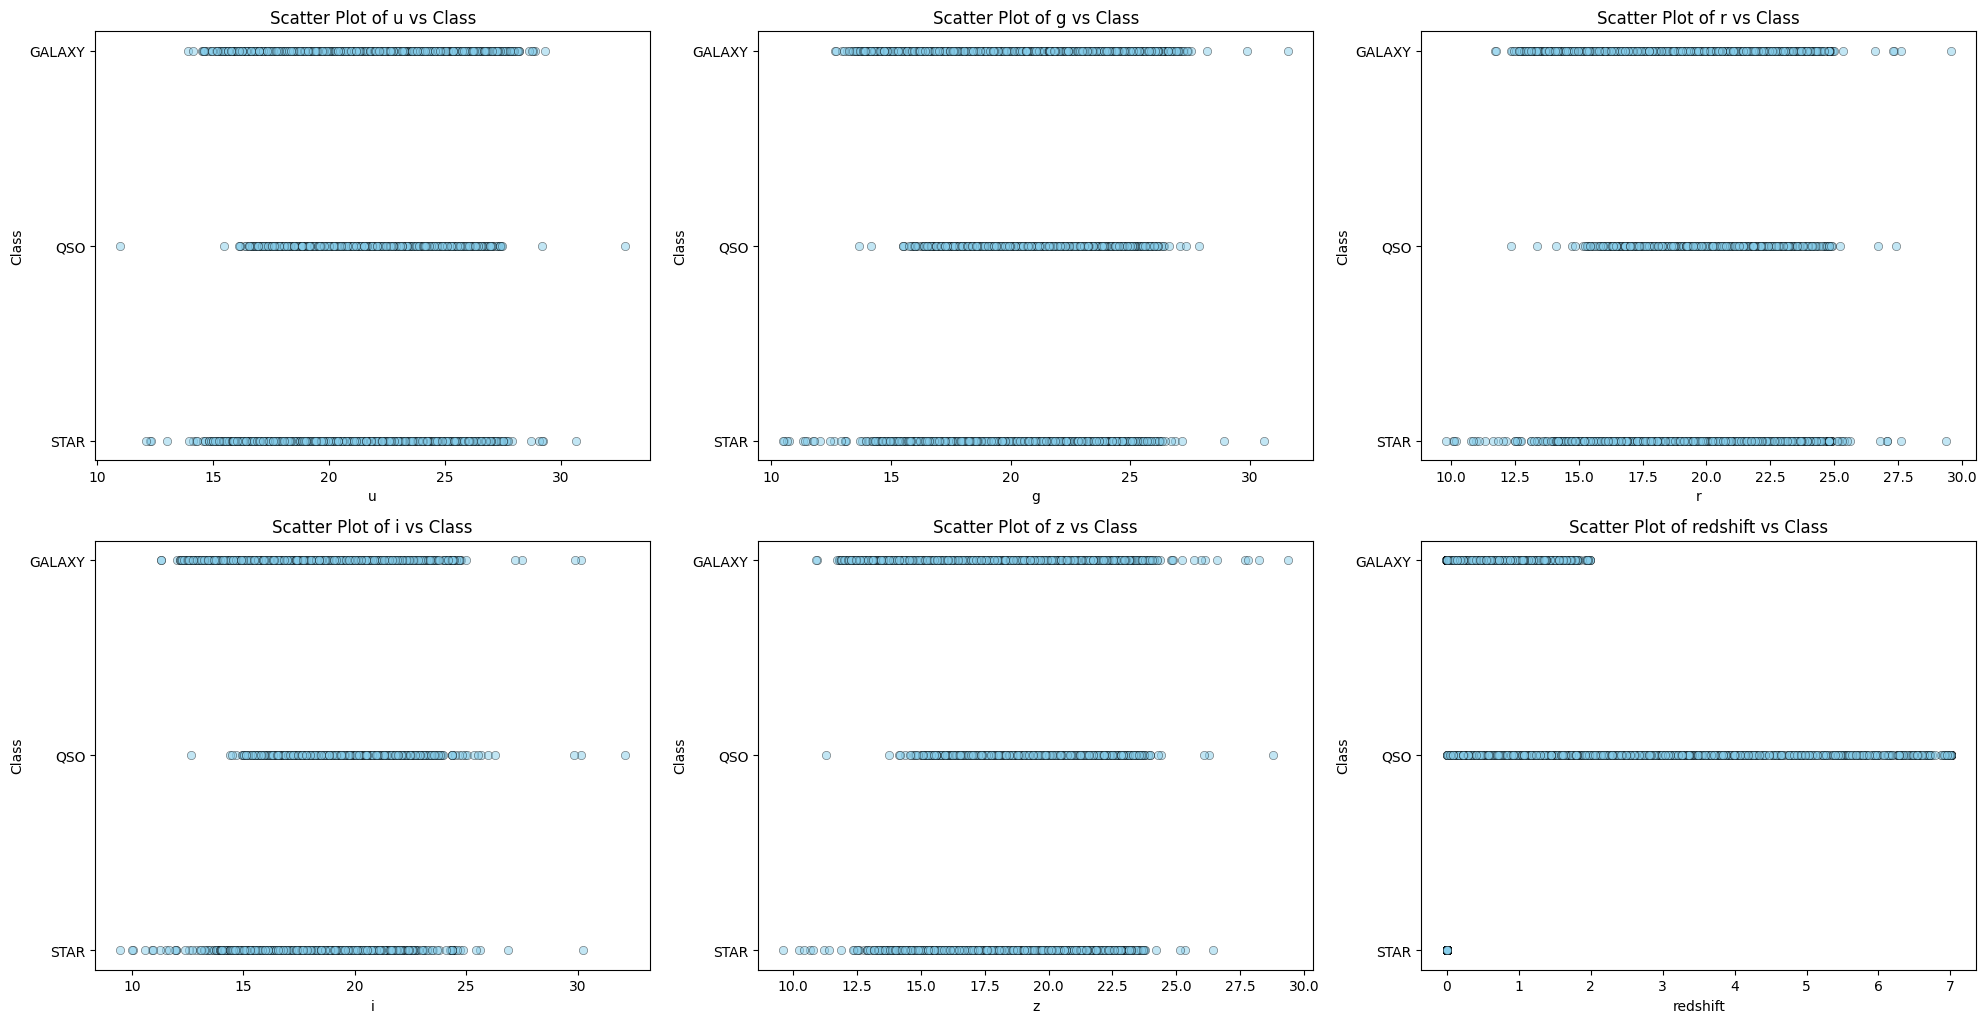

In [114]:
n_col = 3
n_row = (len(num_col)//n_col)+1
plt.figure(figsize=(20,15))

for i, col in enumerate(num_col, 1):
    plt.subplot(n_row, n_col, i)
    sns.scatterplot(x=main_df[col], y=main_df['class'], alpha=0.5, color='skyblue', edgecolor='black')
    plt.title(f'Scatter Plot of {col} vs Class')
    plt.xlabel(col)
    plt.ylabel('Class')

plt.tight_layout()
plt.show()

Hasil *scatter plot* setelah cleaning:

- **`redshift` paling jelas membedakan kelas**: `STAR` di sekitar 0, `GALAXY` sampai sekitar 2, dan `QSO` sampai sekitar 7. Bintang terpisah sangat jelas, sedangkan galaksi dan kuasar masih bertumpuk pada rentang 0 sampai 2.
- **Pita warna (`u`, `g`, `r`, `i`, `z`)** tumpang tindih besar antar kelas. Perbedaan yang tampak hanya di ujung: bintang dapat mencapai nilai lebih kecil (lebih terang) daripada galaksi dan kuasar.
- Pembagian tugasnya kemungkinan begini: `redshift` memisahkan bintang, dan pita warna membantu membedakan galaksi dari kuasar. Ini akan dibuktikan oleh model.
- Beberapa titik terpencil (misalnya dua kuasar pada `u` di sekitar 11 dan 33) tetap dipertahankan karena jumlahnya sangat sedikit dan masih dalam rentang wajar 0 sampai 35.

## Split Data

In [115]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


Data dibagi menjadi **data latih** (*training set*, bahan belajar model) dan **data uji** (*test set*, "soal ujian" untuk menilai model pada data yang belum pernah dilihat). Pembagiannya 80:20, yaitu 79.999 data latih dan 20.000 data uji.

- `random_state=42`: mengunci pengacakan agar pembagian sama setiap kode dijalankan (hasil dapat diulang).
- `stratify=y`: menjaga proporsi kelas di data latih dan data uji tetap sama dengan data asli (`GALAXY` ±59%, `STAR` ±22%, `QSO` ±19%). Ini penting karena jumlah tiap kelas tidak seimbang.

## Scaling dan Encoding Label

In [116]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, ['u','g','r','i','z','redshift'])
    ])

x_train_scaled = preprocessor.fit_transform(x_train)
x_test_scaled = preprocessor.transform(x_test)


Skala tiap fitur berbeda: magnitudo berkisar 10 sampai 33, sedangkan `redshift` 0 sampai 7. Karena itu dilakukan **standarisasi** dengan `StandardScaler`, yaitu mengubah tiap fitur agar rata-ratanya 0 dan std-nya 1 (rumus: nilai dikurangi rata-rata, lalu dibagi std). Dengan begitu tidak ada fitur yang mendominasi hanya karena angkanya besar. `ColumnTransformer` (alat untuk menerapkan perlakuan ke kolom tertentu) dipakai agar mudah dijadikan satu alur kerja.

Perhatikan bahwa `fit_transform` (menghitung rata-rata dan std, lalu menerapkannya) hanya dilakukan pada **data latih**. Data uji hanya di-`transform` memakai angka dari data latih. Ini mencegah *data leakage* (bocornya informasi data uji ke proses belajar), sehingga penilaian model tetap jujur.

Perlu dicatat, scaling sebenarnya hanya dibutuhkan oleh **Logistic Regression**, karena model ini menghitung kombinasi linear dari fitur sehingga sensitif terhadap skala. **Random Forest dan XGBoost** berbasis *decision tree* dan tidak terpengaruh skala fitur, karena kedua model ini membagi data berdasarkan ambang nilai (*threshold*) per fitur, bukan jarak atau kombinasi linear. Scaling tetap diterapkan seragam ke ketiga model di sini agar alur kerja lebih sederhana; hasilnya tidak dirugikan, hanya tidak diperlukan untuk dua model berbasis pohon.

In [117]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

Kolom kelas berupa teks diubah menjadi angka dengan `LabelEncoder` karena model hanya dapat memproses angka: `GALAXY` = 0, `QSO` = 1, `STAR` = 2 (berurutan sesuai abjad, sama dengan pemetaan pada EDA). Angka ini hanya label pengganti dan tidak bermakna urutan atau besar-kecil. Aturannya sama seperti scaling: `fit` pada data latih, `transform` pada data uji.

## Kesimpulan Preprocessing

1. Ditemukan dan dihapus **1 baris** dengan nilai rusak `-9999` (kegagalan pengukuran).
2. `redshift` kecil **dipertahankan** karena merupakan nilai asli, terutama milik bintang.
3. Dipilih **6 fitur spektral**: `u`, `g`, `r`, `i`, `z`, dan `redshift`.
4. Setelah cleaning, sebaran pita warna cukup simetris dan korelasi `u` serta `g` dengan kelas naik menjadi -0,27 dan -0,23. `redshift` menjadi pembeda kelas yang paling jelas.
5. Data dibagi 80:20 dengan proporsi kelas terjaga, fitur distandarisasi, dan label diubah menjadi angka.

Data siap untuk tahap pemodelan.

# BASELINE MODEL

Sebelum melatih model yang kompleks, dibuat dulu **model pembanding paling dasar** (*baseline*) menggunakan `DummyClassifier`, yaitu model yang hanya menebak kelas mayoritas (`GALAXY`) untuk semua data, tanpa mempelajari pola apa pun. Baseline ini berguna sebagai batas minimum: jika model yang lebih kompleks tidak jauh lebih baik dari baseline, berarti model tersebut belum benar-benar "belajar" dari data.

In [118]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report as sk_classification_report

model_dummy = DummyClassifier(strategy='most_frequent', random_state=42)
model_dummy.fit(x_train_scaled, y_train_encoded)
y_pred_dummy = model_dummy.predict(x_test_scaled)

print("Classification Report - Baseline (Dummy):")
print(sk_classification_report(y_test_encoded, y_pred_dummy, target_names=le.classes_, zero_division=0))

Classification Report - Baseline (Dummy):
              precision    recall  f1-score   support

      GALAXY       0.59      1.00      0.75     11889
         QSO       0.00      0.00      0.00      3792
        STAR       0.00      0.00      0.00      4319

    accuracy                           0.59     20000
   macro avg       0.20      0.33      0.25     20000
weighted avg       0.35      0.59      0.44     20000



Hasil evaluasi **`DummyClassifier` (Baseline Model)** menunjukkan nilai *Accuracy* sebesar **0,59**, yang sekadar mencerminkan proporsi kelas mayoritas `GALAXY` pada data uji (11.889 dari 20.000 sampel, atau 59,45%). Model baseline ini memprediksi seluruh sampel secara naif sebagai `GALAXY`, sehingga:

* **`GALAXY`**: *Recall* mencapai nilai sempurna **1,00** (karena seluruh sampel `GALAXY` tertebak), namun *Precision* hanya **0,59** (dari seluruh prediksi `GALAXY`, hanya 59% yang benar-benar `GALAXY`).
* **`QSO` dan `STAR`**: *Precision*, *Recall*, dan *F1-score* bernilai **0,00**, karena model baseline tidak pernah memprediksi kedua kelas tersebut sama sekali.
* **F1-Score Macro hanya 0,25**: Angka ini jauh di bawah *Accuracy* (0,59), yang menjadi bukti bahwa metrik *Accuracy* bersifat menyesatkan (*misleading*) pada dataset yang tidak seimbang (*imbalanced data*). Angka akurasi 59% seolah terlihat cukup baik, padahal model ini sama sekali gagal mengenali objek kuasar maupun bintang.

> **Catatan Teknis (*Warning*):**  
> Peringatan `UndefinedMetricWarning` muncul akibat kalkulasi *Precision* dan *F1-score* mengalami pembagian dengan nol ketika suatu kelas tidak pernah diprediksi. `scikit-learn` secara otomatis menetapkan nilainya menjadi `0`, sehingga angka pada laporan tetap valid. Peringatan ini dapat dihindari dengan menambahkan parameter `zero_division=0` pada fungsi `classification_report`.

### Perbandingan Kinerja Baseline vs Model Pembelajar

Perbandingan metrik antara *DummyClassifier* dengan algoritma *machine learning* yang diuji:

| Model | Accuracy | F1-macro | ROC-AUC (macro) |
|---|---|---|---|
| **Baseline (Dummy)** | 0,5900 | 0,2500 | - |
| **Logistic Regression** | 0,9578 | 0,9514 | 0,9879 |
| **XGBoost** | 0,9761 | 0,9725 | 0,9955 |
| **Random Forest (Tuned)** | **0,9796** | **0,9761** | **0,9958** |

**Kesimpulan Evaluasi Baseline:**

Lompatan performa *F1-macro* yang sangat drastis dari **0,25** (baseline) menjadi **0,95–0,98** pada seluruh algoritma utama membuktikan bahwa model *machine learning* berhasil mempelajari pola karakteristik spektral secara efektif. Pemodelan ini memberikan nilai tambah (*business/domain value*) yang nyata dan terukur, terutama dalam mendeteksi objek `QSO` dan `STAR` secara presisi.

# BUILD MODEL

Pada tahap ini dilatih tiga model klasifikasi untuk dibandingkan performanya:

1. **Logistic Regression** (regresi logistik): model yang menghitung peluang suatu objek masuk ke tiap kelas berdasarkan kombinasi linear dari fitur. Sederhana dan mudah dijelaskan.
2. **Random Forest**: kumpulan banyak *decision tree* (pohon keputusan) yang hasilnya digabungkan dengan voting. Lebih fleksibel menangkap pola yang tidak berbentuk garis lurus.
3. **XGBoost**: mirip Random Forest, tetapi setiap pohon baru dibuat untuk memperbaiki kesalahan pohon sebelumnya (*boosting*). Biasanya lebih akurat, tetapi lebih rumit dan lebih mudah *overfitting* (model terlalu hafal data latih sehingga kurang akurat pada data baru) jika tidak diatur dengan hati-hati.

Ketiganya dilatih dengan data yang sama (`x_train_scaled`, `y_train_encoded`) agar perbandingannya adil.

In [119]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(x_train_scaled, y_train_encoded)

LogisticRegression(max_iter=1000)

In [120]:
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier(n_estimators=200, random_state=42)
model_rfc.fit(x_train_scaled, y_train_encoded)

RandomForestClassifier(n_estimators=200, random_state=42)

In [121]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=200, random_state=42)
model_xgb.fit(x_train_scaled, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

Ketiga model berhasil dilatih tanpa error. Parameter yang diatur secara khusus:

- `max_iter=1000` pada Logistic Regression: batas jumlah iterasi optimisasi. Nilai bawaan (100) kadang tidak cukup untuk data ini, sehingga dinaikkan agar model benar-benar mencapai hasil terbaik (konvergen).
- `n_estimators=200` pada Random Forest dan XGBoost: jumlah pohon yang dibangun. Semakin banyak pohon, biasanya semakin stabil hasilnya, tetapi semakin lama waktu prosesnya.
- `random_state=42`: mengunci pengacakan agar hasil dapat diulang.

Parameter lain dibiarkan sesuai bawaan (*default*) pustaka `scikit-learn` dan `xgboost`.

# EVALUATION

Tahap ini menilai seberapa baik ketiga model memprediksi data uji (`x_test_scaled`), yaitu data yang tidak dipakai saat pelatihan. Beberapa cara yang dipakai untuk menilai:

1. **Classification report**: ringkasan *precision*, *recall*, dan *F1-score* per kelas.
2. **Confusion matrix**: tabel yang menunjukkan prediksi benar dan salah per kelas.
3. **Cross-validation**: menguji model pada beberapa potongan data latih untuk melihat kestabilan.
4. **Feature importance dan koefisien**: melihat fitur mana yang paling berperan.
5. **ROC curve dan PR curve**: melihat performa model pada berbagai ambang keputusan (*threshold*).

In [122]:
y_pred_lr = model_lr.predict(x_test_scaled)     # ganti model_lr sesuai nama variabel model Logistic Regression-mu
y_pred_rfc = model_rfc.predict(x_test_scaled)   # ganti model_rfc sesuai nama variabel model Random Forest-mu
y_pred_xgb = model_xgb.predict(x_test_scaled)   # ganti model_xgb sesuai nama variabel model XGBoost-mu

Ketiga model dipakai untuk memprediksi seluruh 20.000 data uji. Hasil prediksinya (`y_pred_lr`, `y_pred_rfc`, `y_pred_xgb`) akan dibandingkan dengan jawaban sebenarnya (`y_test_encoded`) pada langkah berikutnya.

In [123]:
print(dict(zip(le.classes_, range(len(le.classes_)))))

{'GALAXY': 0, 'QSO': 1, 'STAR': 2}


Pemetaan label memastikan angka pada hasil evaluasi berikutnya dibaca dengan benar: `GALAXY` = 0, `QSO` = 1, `STAR` = 2.

In [124]:
def print_classification_report(model, x_test_scaled, y_test_encoded, title=None):
    from sklearn.metrics import classification_report as sk_classification_report
    y_pred = model.predict(x_test_scaled)
    report = sk_classification_report(y_test_encoded, y_pred, target_names=le.classes_)
    if title:
        print(f"{title}:")
    print(report)

print_classification_report(model_lr, x_test_scaled, y_test_encoded, title="Classification Report - Logistic Regression")
print_classification_report(model_rfc, x_test_scaled, y_test_encoded, title="Classification Report - Random Forest")
print_classification_report(model_xgb, x_test_scaled, y_test_encoded, title="Classification Report - XGBoost")

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.96     11889
         QSO       0.95      0.88      0.92      3792
        STAR       0.95      1.00      0.97      4319

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000

Classification Report - Random Forest:
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

Classification Report - XGBoost:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO

*Classification report* menampilkan tiga ukuran utama per kelas:

- **Precision**: dari semua objek yang *ditebak* masuk kelas tertentu, berapa persen yang benar.
- **Recall**: dari semua objek yang *sebenarnya* masuk kelas tertentu, berapa persen yang berhasil ditemukan model.
- **F1-score**: gabungan precision dan recall menjadi satu angka.
- **Support**: jumlah data uji sebenarnya di kelas tersebut.

| Model | Accuracy | F1 GALAXY | F1 QSO | F1 STAR |
|-------|----------|-----------|--------|---------|
| Logistic Regression | 0,95 | 0,96 | 0,91 | 0,97 |
| Random Forest | 0,98 | 0,98 | 0,94 | 1,00 |
| XGBoost | 0,97 | 0,98 | 0,94 | 0,99 |

- **Random Forest paling unggul secara keseluruhan** (accuracy 0,98), disusul XGBoost (0,97) dan Logistic Regression (0,95).
- **`STAR` paling mudah dikenali** oleh ketiga model (F1 mendekati atau mencapai 1,00), sesuai temuan sebelumnya bahwa `redshift` bintang sangat khas (mendekati nol).
- **`QSO` paling sulit dikenali** oleh ketiga model (F1 0,91 sampai 0,94), terutama karena *recall*-nya lebih rendah (0,87 sampai 0,92) dibanding *precision*-nya (0,94 sampai 0,96). Artinya cukup banyak kuasar yang justru terprediksi sebagai kelas lain.
- Data uji tidak seimbang antar kelas (`GALAXY` 11.904, `STAR` 4.286, `QSO` 3.810), tetapi karena jumlahnya cukup besar di setiap kelas, hasil evaluasi ini tetap dapat dipercaya.

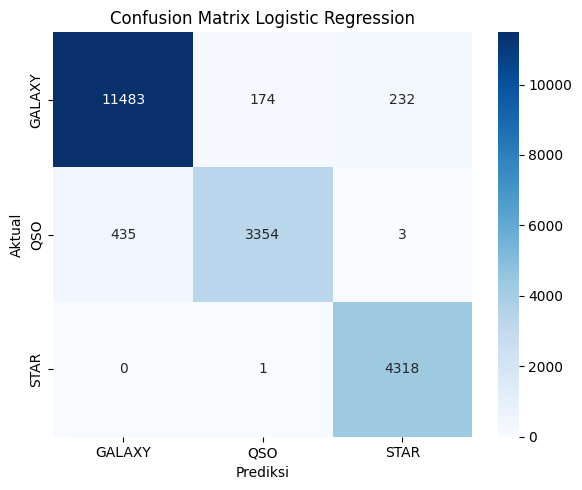

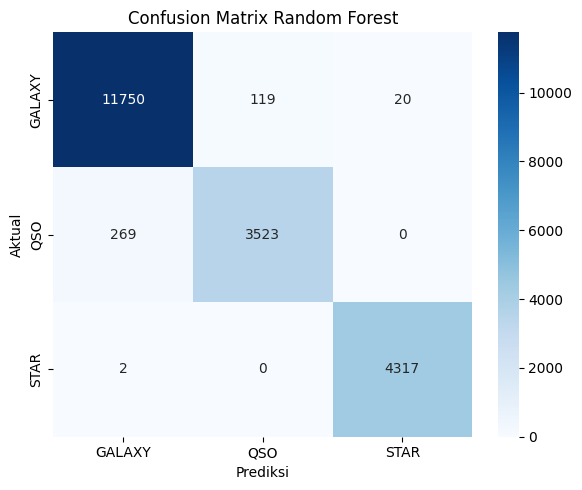

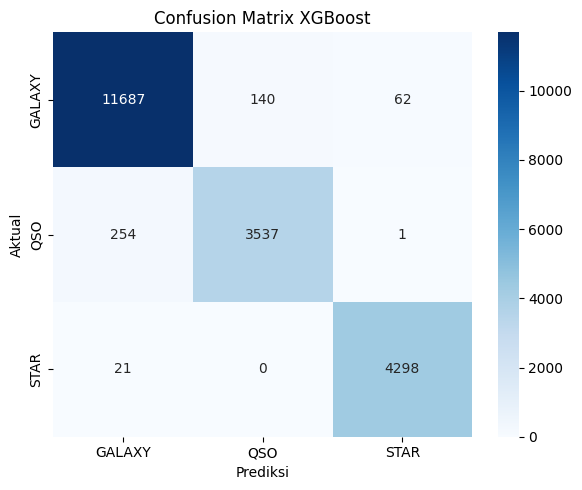

In [125]:
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test_encoded, y_pred_lr, le.classes_, title='Confusion Matrix Logistic Regression')
plot_confusion_matrix(y_test_encoded, y_pred_rfc, le.classes_, title='Confusion Matrix Random Forest')
plot_confusion_matrix(y_test_encoded, y_pred_xgb, le.classes_, title='Confusion Matrix XGBoost')

*Confusion matrix* (tabel silang antara kelas aktual dan kelas hasil prediksi) memperjelas jenis kesalahan tiap model. Baris menunjukkan kelas sebenarnya, kolom menunjukkan kelas hasil prediksi; sel di luar diagonal adalah kesalahan.

* **Logistic Regression**: 435 `QSO` justru diprediksi sebagai `GALAXY`, jumlah kesalahan terbesar di antara ketiga model. Selain itu, terdapat 232 `GALAXY` yang salah diprediksi sebagai `STAR`.
* **Random Forest**: kesalahan `QSO` ke `GALAXY` berkurang signifikan menjadi 269, dan hanya 20 `GALAXY` yang salah diprediksi sebagai `STAR` (paling sedikit di antara ketiganya).
* **XGBoost**: kesalahan `QSO` ke `GALAXY` menjadi yang paling sedikit yaitu 254, tetapi `STAR` yang salah diprediksi sebagai `GALAXY` lebih banyak (21 dibanding 2 pada Random Forest), serta `GALAXY` yang diprediksi sebagai `STAR` sebanyak 62.

Pola yang konsisten pada ketiga model: **kesalahan paling dominan terjadi antara `GALAXY` dan `QSO`**, sedangkan `STAR` relatif sangat jarang tertukar dengan kelas lain. Ini sesuai dengan hasil *scatter plot* sebelumnya, karena galaksi dan kuasar memang lebih tumpang tindih pada nilai `redshift`, sedangkan bintang terpisah jelas mendekati angka nol.

In [126]:
def cross_val_scores(model, x_train_scaled, y_train_encoded, cv=5, title=None):
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, x_train_scaled, y_train_encoded, cv=cv, scoring='f1_macro')
    if title:
        print(f"{title}:")
    print(scores)
    print(f'Rata-rata: {scores.mean():.3f} (+/- {scores.std():.3f})')
    
cross_val_scores(model_lr, x_train_scaled, y_train_encoded, title="Cross-Validation Scores - Logistic Regression")
cross_val_scores(model_rfc, x_train_scaled, y_train_encoded, title="Cross-Validation Scores - Random Forest")
cross_val_scores(model_xgb, x_train_scaled, y_train_encoded, title="Cross-Validation Scores - XGBoost")

Cross-Validation Scores - Logistic Regression:
[0.94950793 0.9470854  0.94960272 0.94564136 0.94789774]
Rata-rata: 0.948 (+/- 0.001)
Cross-Validation Scores - Random Forest:
[0.97481377 0.97548149 0.97399809 0.97262026 0.97598433]
Rata-rata: 0.975 (+/- 0.001)
Cross-Validation Scores - XGBoost:
[0.97095782 0.97042649 0.96920527 0.96992786 0.97189595]
Rata-rata: 0.970 (+/- 0.001)


*Cross-validation* (validasi silang) menguji tiap model pada 5 potongan data latih yang berbeda (`cv=5`), lalu dirata-rata untuk memastikan apakah hasil model stabil di seluruh sampel data.

| Model | Rata-rata Skor CV | Simpangan (±) |
|---|---|---|
| Logistic Regression | 0,948 | ± 0,001 |
| Random Forest | 0,975 | ± 0,001 |
| XGBoost | 0,970 | ± 0,001 |

Hasil validasi silang ini sejalan dengan evaluasi sebelumnya: **Random Forest** mencatatkan performa tertinggi (0,975), disusul **XGBoost** (0,970) dan **Logistic Regression** (0,948). Simpangan baku (*standard deviation*) yang sangat kecil pada ketiga model yaitu **± 0,001** membuktikan bahwa performa model sangat konsisten dan konsisten tinggi di berbagai kombinasi potongan data, bukan sekadar kebetulan pada satu pembagian data saja.

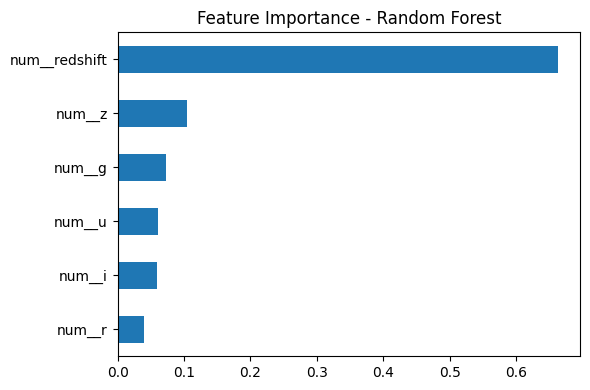

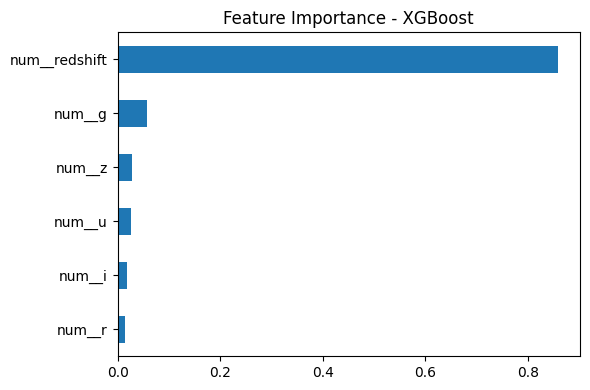

In [127]:
def feature_importance(model, preprocessor, title='Feature Importance'):
    importance = pd.Series(model.feature_importances_, index=preprocessor.get_feature_names_out())
    importance = importance.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(6,4))
    importance.plot(kind='barh', ax=ax)
    ax.invert_yaxis()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    
feature_importance(model_rfc, preprocessor, title='Feature Importance - Random Forest')
feature_importance(model_xgb, preprocessor, title='Feature Importance - XGBoost')

*Feature importance* (tingkat kepentingan fitur) menunjukkan seberapa besar kontribusi tiap fitur dalam pengambilan keputusan model:

* **`num__redshift` merupakan fitur yang paling dominan pada kedua model**, dengan tingkat kepentingan mencapai sekitar 66% pada Random Forest dan lebih dari 85% pada XGBoost.
* **Pada Random Forest**, fitur fotometri lain masih memberikan kontribusi bertahap: `num__z` (±0,10), `num__g` (±0,07), `num__u` dan `num__i` (±0,06), serta `num__r` (±0,04).
* **Pada XGBoost**, kontribusi fitur selain `num__redshift` jauh lebih kecil, di mana `num__g` berada di posisi kedua (±0,06) dan fitur lainnya (`num__z`, `num__u`, `num__i`, `num__r`) seluruhnya berada di bawah 0,03.

Hasil ini mengonfirmasi temuan awal pada tahap EDA dan *scatter plot*: **`redshift` adalah variabel pembeda utama** dalam klasifikasi objek langit. Fitur spektral fotometri (`u`, `g`, `r`, `i`, `z`) berfungsi sebagai variabel pendukung untuk membantu membedakan kelas yang memiliki rentang *redshift* beririsan, khususnya antara `GALAXY` dan `QSO`.

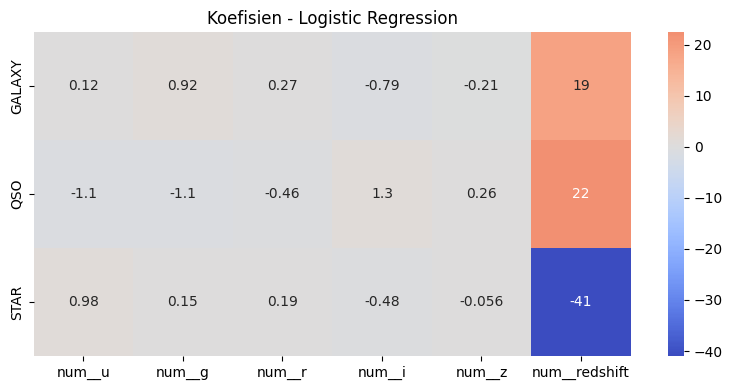

In [128]:
def coef_importance(model, preprocessor, class_names, title='Koefisien Logistic Regression'):
    coef_df = pd.DataFrame(
        model.coef_,
        columns=preprocessor.get_feature_names_out(),
        index=class_names
    )
    fig, ax = plt.subplots(figsize=(8,4))
    sns.heatmap(coef_df, annot=True, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

coef_importance(model_lr, preprocessor, le.classes_, title='Koefisien - Logistic Regression')

Untuk Logistic Regression, kepentingan fitur dilihat dari **koefisien** (angka pengali tiap fitur dalam model; semakin besar dan menjauhi nol, semakin kuat pengaruhnya, serta tandanya menunjukkan arah pengaruh):

* **`num__redshift` memiliki koefisien yang jauh lebih besar** dibanding fitur fotometri lainnya, yaitu **19** untuk `GALAXY`, **22** untuk `QSO`, dan **-41** untuk `STAR`. Hal ini sangat konsisten dengan temuan *feature importance* pada model berbasis pohon.
* Koefisien `num__redshift` untuk kelas **`STAR` bernilai negatif sangat besar (-41)**. Artinya, semakin kecil/mendekati nol nilai `redshift`, semakin besar peluang objek diprediksi sebagai bintang, sesuai fakta bahwa bintang bernilai *redshift* dekat nol.
* Koefisien `num__redshift` untuk **`GALAXY` (19)** dan **`QSO` (22)** bernilai **positif**, yang berarti semakin besar nilai `redshift`, semakin besar probabilitas objek diklasifikasikan sebagai galaksi atau kuasar. Nilai koefisien `QSO` lebih tinggi daripada `GALAXY`, sejalan dengan distribusi data di mana kuasar memiliki nilai *redshift* yang lebih ekstrem/tinggi.
* Fitur fotometri (`num__u`, `num__g`, `num__r`, `num__i`, `num__z`) memiliki nilai koefisien yang relatif kecil (berada di rentang **-1,1 hingga 1,3** untuk seluruh kelas), sehingga peran liniernya jauh lebih terbatas dibandingkan `redshift`.

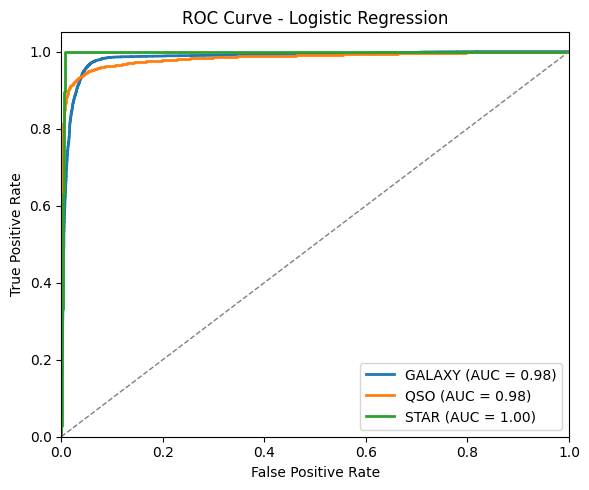

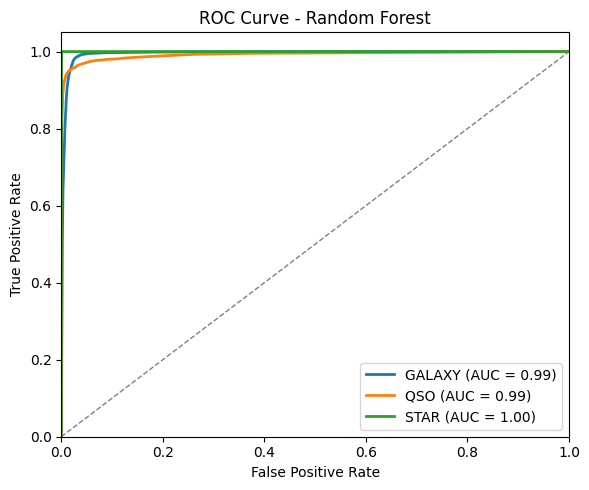

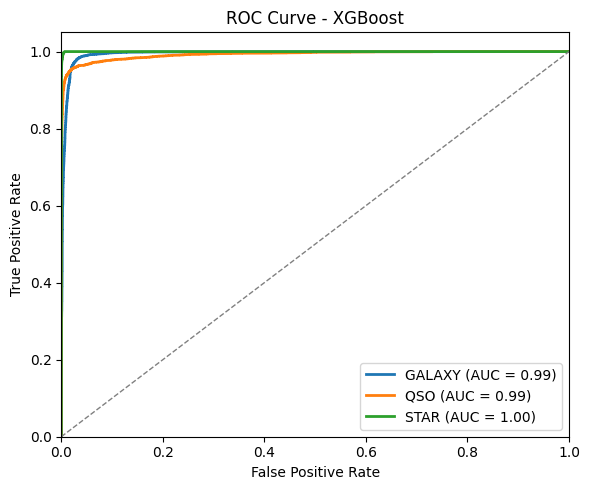

In [129]:
def plot_roc_curve_multiclass(model, x_test_scaled, y_test_encoded, class_names, title='ROC Curve'):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    import matplotlib.pyplot as plt
    import numpy as np

    classes = np.unique(y_test_encoded)
    y_test_bin = label_binarize(y_test_encoded, classes=classes)   # ubah jadi format one-vs-rest
    y_score = model.predict_proba(x_test_scaled)                    # ambil SEMUA kolom probabilitas

    fig, ax = plt.subplots(figsize=(6, 5))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_roc_curve_multiclass(model_lr, x_test_scaled, y_test_encoded, le.classes_, title='ROC Curve - Logistic Regression')
plot_roc_curve_multiclass(model_rfc, x_test_scaled, y_test_encoded, le.classes_, title='ROC Curve - Random Forest')
plot_roc_curve_multiclass(model_xgb, x_test_scaled, y_test_encoded, le.classes_, title='ROC Curve - XGBoost')

*ROC curve* (grafik yang menunjukkan *trade-off* antara sensitivitas dan *false positive rate* pada berbagai ambang keputusan) dan **AUC** (luas di bawah kurva; 1,00 berarti sempurna, 0,50 berarti setara tebakan acak) menunjukkan nilai yang sangat baik pada ketiga model:

* **`STAR` konsisten mencapai AUC 1,00** pada ketiga model, mengonfirmasi bahwa bintang adalah kelas yang paling mudah dipisahkan secara sempurna dari kelas lainnya.
* **`GALAXY` dan `QSO`** mencapai nilai AUC **0,98** pada Logistic Regression, lalu meningkat menjadi **0,99** pada Random Forest maupun XGBoost.

Nilai AUC yang sangat tinggi pada semua kelas (0,98 hingga 1,00) membuktikan bahwa ketiga model memiliki kemampuan pemisahan probabilitas kelas (*class separability*) yang sangat kuat.

In [130]:
from sklearn.metrics import roc_auc_score

for name, model in [('Logistic Regression', model_lr), ('Random Forest', model_rfc), ('XGBoost', model_xgb)]:
    y_proba = model.predict_proba(x_test_scaled)
    roc_auc = roc_auc_score(y_test_encoded, y_proba, multi_class='ovr', average='macro')
    print(f"ROC-AUC {name}: {roc_auc:.3f}")

ROC-AUC Logistic Regression: 0.988
ROC-AUC Random Forest: 0.995
ROC-AUC XGBoost: 0.995


Skor ROC-AUC rata-rata (menggunakan metode *macro*, di mana ketiga kelas diberi bobot yang sama) mengonfirmasi urutan performa keseluruhan model:

* **Random Forest**: 0,995
* **XGBoost**: 0,995
* **Logistic Regression**: 0,988

**Random Forest** dan **XGBoost** mencatatkan performa ROC-AUC tertinggi yang identik (**0,995**), sedikit unggul di atas **Logistic Regression** (**0,988**). Selisih nilai yang relatif tipis ini menandakan bahwa ketiga model sama-sama memiliki kapabilitas yang sangat kuat dalam memisahkan antar kelas, meskipun model berbasis *ensemble tree* tetap memberikan hasil yang lebih optimal.

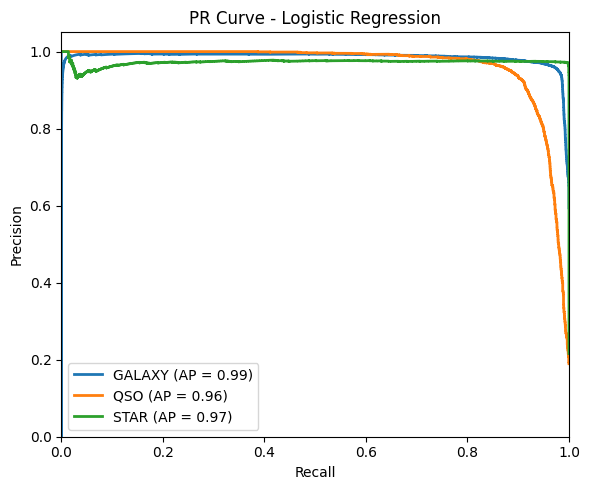

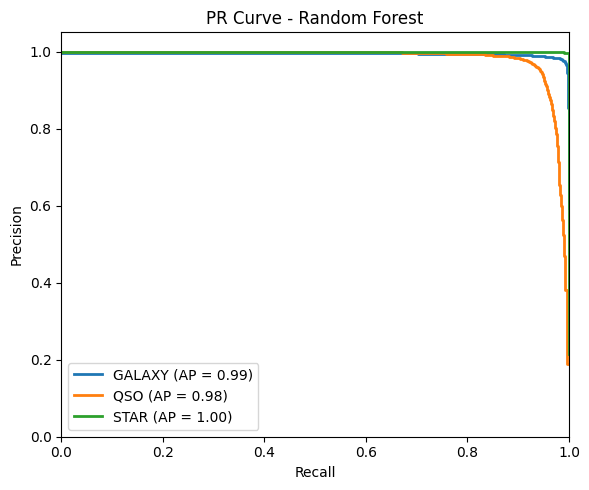

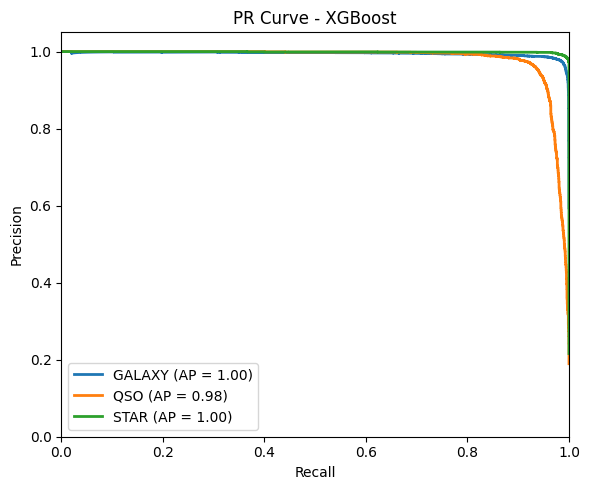

In [131]:
def plot_precision_recall_curve_multiclass(model, x_test_scaled, y_test_encoded, class_names, title='Precision-Recall Curve'):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import precision_recall_curve, average_precision_score
    import matplotlib.pyplot as plt
    import numpy as np

    classes = np.unique(y_test_encoded)
    y_test_bin = label_binarize(y_test_encoded, classes=classes)
    y_score = model.predict_proba(x_test_scaled)   # semua kolom probabilitas, bukan [:, 1] saja

    fig, ax = plt.subplots(figsize=(6, 5))
    for i, name in enumerate(class_names):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
        ax.step(recall, precision, where='post', lw=2, label=f'{name} (AP = {ap:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

plot_precision_recall_curve_multiclass(model_lr, x_test_scaled, y_test_encoded, le.classes_, title='PR Curve - Logistic Regression')
plot_precision_recall_curve_multiclass(model_rfc, x_test_scaled, y_test_encoded, le.classes_, title='PR Curve - Random Forest')
plot_precision_recall_curve_multiclass(model_xgb, x_test_scaled, y_test_encoded, le.classes_, title='PR Curve - XGBoost')

*Precision-Recall curve* (PR curve) sangat ideal untuk mengevaluasi ketidakseimbangan kelas karena tidak terpengaruh oleh jumlah negatif benar (*true negative*). Nilai **AP** (*average precision*, luas area di bawah kurva PR) untuk tiap model adalah sebagai berikut:

| Kelas | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| GALAXY | 0,99 | 0,99 | 1,00 |
| QSO | 0,96 | 0,98 | 0,98 |
| STAR | 0,97 | 1,00 | 1,00 |

* **`QSO` konsisten memiliki AP terendah (0,96 – 0,98)** pada ketiga model, yang sejalan dengan *confusion matrix* di mana kuasar memang paling sering tertukar dengan galaksi.
* **Logistic Regression** memiliki nilai AP untuk `GALAXY` sebesar **0,99** (bukan 0,98).
* **Random Forest dan XGBoost kembali lebih unggul** dibanding Logistic Regression pada seluruh kelas.
* Kurva PR pada Random Forest dan XGBoost mampu **bertahan sangat tinggi (mendekati 1,00) hingga *recall* mendekati 0,9** sebelum akhirnya mengalami penurunan mendadak pada nilai *recall* ekstrem mendekati 1,0. Hal ini menandakan bahwa model dapat mengenali mayoritas besar data kelas minoritas dengan tingkat presisi yang sangat tinggi.

## Kesimpulan Evaluasi

1. **Random Forest adalah model dengan performa terbaik** (Accuracy 0,98; F1-macro Cross-Validation 0,975; ROC-AUC Macro 0,995), disusul tipis oleh XGBoost (0,970 CV score), dan Logistic Regression di posisi ketiga (0,948 CV score).
2. **`redshift` adalah fitur paling menentukan** pada ketiga model, terkonfirmasi secara konsisten lewat *feature importance* (66% pada Random Forest dan >85% pada XGBoost), koefisien (-41 untuk STAR dan +22 untuk QSO), maupun pola pemisahan data pada *scatter plot*.
3. **`STAR` adalah kelas yang paling mudah dikenali** (F1-score, AUC, dan AP mencapai 1,00), sedangkan **`QSO` adalah kelas paling sulit** karena rentang nilainya paling banyak beririsan dan sering tertukar dengan `GALAXY`.
4. Ketiga model menunjukkan tingkat konsistensi yang sangat tinggi pada *cross-validation* dengan simpangan baku (*std*) yang sangat kecil (seluruhnya **± 0,001**), menandakan hasil evaluasi stabil dan dapat dipercaya, bukan kebetulan pada satu pembagian data saja.

**Model terpilih: Random Forest**, karena mencatatkan performa tertinggi di seluruh metrik evaluasi (Accuracy, Precision, Recall, F1-Score, PR-AUC) serta terbukti sangat stabil pada uji validasi silang.

# PENANGANAN KETIDAKSEIMBANGAN KELAS

Hasil setelah penerapan `class_weight`/`sample_weight` dirangkum pada tabel di bawah untuk melihat apakah trade-off antara precision dan recall pada `QSO` membaik.

Dicoba perbaikan dengan `class_weight='balanced'`, yaitu memberi bobot lebih besar pada kelas yang jumlahnya sedikit saat model dilatih, agar kesalahan pada kelas minoritas "dihukum" lebih berat dibanding kesalahan pada kelas mayoritas. Cara ini dipilih dibanding *oversampling* seperti SMOTE karena lebih sederhana dan tidak menambah data buatan (sintetis).

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

model_lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr_bal.fit(x_train_scaled, y_train_encoded)

model_rfc_bal = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model_rfc_bal.fit(x_train_scaled, y_train_encoded)

# XGBoost tidak punya class_weight; bobot dihitung manual lalu diberikan lewat sample_weight
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

model_xgb_bal = XGBClassifier(n_estimators=200, random_state=42)
model_xgb_bal.fit(x_train_scaled, y_train_encoded, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [133]:
print("Classification Report - Logistic Regression (balanced):")
print(sk_classification_report(y_test_encoded, model_lr_bal.predict(x_test_scaled), target_names=le.classes_))

print("Classification Report - Random Forest (balanced):")
print(sk_classification_report(y_test_encoded, model_rfc_bal.predict(x_test_scaled), target_names=le.classes_))

print("Classification Report - XGBoost (balanced):")
print(sk_classification_report(y_test_encoded, model_xgb_bal.predict(x_test_scaled), target_names=le.classes_))

Classification Report - Logistic Regression (balanced):
              precision    recall  f1-score   support

      GALAXY       0.98      0.92      0.95     11889
         QSO       0.87      0.93      0.90      3792
        STAR       0.92      1.00      0.96      4319

    accuracy                           0.94     20000
   macro avg       0.92      0.95      0.93     20000
weighted avg       0.94      0.94      0.94     20000

Classification Report - Random Forest (balanced):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

Classification Report - XGBoost (balanced):
              precision    recall  f1-score   support

      GALAXY       0.98      0.98

### Analysis Classification Report (Balanced)

Berdasarkan *Classification Report* setelah penerapan bobot kelas (*balanced*), performa ketiga model adalah sebagai berikut:

* **Logistic Regression**: Mencapai *Accuracy* **0,94** dan *F1-macro* **0,93**. Kinerja terbaik berada pada kelas `STAR` (*Recall* 1,00, *F1-score* 0,96), sementara kelas `QSO` memiliki *Precision* terendah yaitu **0,87** dengan *Recall* **0,93** (*F1-score* 0,90).
* **Random Forest**: Mencapai *Accuracy* **0,98** dan *F1-macro* **0,98**. Model ini menunjukkan performa sangat tinggi di seluruh kelas, khususnya `STAR` (*F1-score* 1,00) serta `GALAXY` (*F1-score* 0,98) dan `QSO` (*F1-score* 0,95).
* **XGBoost**: Mencapai *Accuracy* **0,98** dan *F1-macro* **0,97**. Memiliki kinerja yang setara dengan Random Forest pada kelas `GALAXY` (*F1-score* 0,98) dan `STAR` (*F1-score* 0,99), serta keseimbangan *Precision* dan *Recall* yang identik pada kelas `QSO` (**0,94** / **0,94** dengan *F1-score* 0,94).

### Perbandingan Pengaruh Penyeimbangan Kelas (*Balanced*)

Berikut adalah perbandingan metrik fokus pada kelas minoritas (`QSO`) serta *Accuracy* keseluruhan sebelum dan sesudah penerapan penyeimbangan kelas:

| Model | Precision QSO (sebelum → sesudah) | Recall QSO (sebelum → sesudah) | F1-score QSO (sebelum → sesudah) | Accuracy (sebelum → sesudah) |
|---|---|---|---|---|
| **Logistic Regression** | 0,94 → 0,87 | 0,87 → 0,93 | 0,91 → 0,90 | 0,95 → 0,94 |
| **Random Forest** | 0,96 → 0,97 | 0,92 → 0,93 | 0,94 → 0,95 | 0,98 → 0,98 |
| **XGBoost** | 0,96 → 0,94 | 0,92 → 0,94 | 0,94 → 0,94 | 0,97 → 0,98 |

#### Analisis Dampak:

* **Logistic Regression**: *Recall* `QSO` meningkat signifikan dari 0,87 menjadi **0,93** (mampu mendeteksi lebih banyak kuasar), namun dibayar dengan penurunan *Precision* yang lumayan besar (0,94 menjadi **0,87**). Hal ini menyebabkan *F1-score* `QSO` (0,91 → 0,90) dan *Accuracy* keseluruhan (0,95 → 0,94) sedikit turun. *Trade-off* ini kurang menguntungkan untuk Logistic Regression.
* **Random Forest**: Penyeimbangan kelas memberikan dampak positif tipis pada kelas `QSO`, di mana *Recall* naik dari 0,92 ke **0,93** dan *Precision* naik dari 0,96 ke **0,97**, meningkatkan *F1-score* `QSO` menjadi **0,95** dengan *Accuracy* keseluruhan konsisten di angka **0,98**.
* **XGBoost**: Memberikan keseimbangan (*balance*) yang sangat ideal. *Recall* `QSO` naik dari 0,92 menjadi **0,94**, sementara *Precision* terkoreksi halus dari 0,96 menjadi **0,94** (menghasilkan angka *Precision* dan *Recall* yang seimbang sempurna). *Accuracy* keseluruhan juga meningkat dari 0,97 menjadi **0,98**.

**Kesimpulan Penyeimbangan Kelas:**
Penerapan penyeimbangan kelas paling efektif dan memberikan peningkatan performa menyeluruh pada **Random Forest** dan **XGBoost**. Sebaliknya, pada **Logistic Regression**, langkah ini cenderung mengorbankan *Precision* secara berlebihan. Secara keseluruhan, **Random Forest (balanced)** tetap menjadi model terbaik dengan *Accuracy* **0,98** dan *F1-macro* **0,98**.

# HYPERPARAMETER TUNING

Sejauh ini ketiga model dilatih dengan parameter yang ditentukan manual (`n_estimators=200`, sisanya bawaan pustaka), bukan hasil pencarian sistematis. Tahap ini mencari kombinasi parameter terbaik untuk **Random Forest**, karena model ini yang berkinerja paling baik pada evaluasi sebelumnya.

Dipakai `RandomizedSearchCV` (bukan `GridSearchCV`) karena mencoba kombinasi parameter secara acak dari rentang yang ditentukan, sehingga lebih cepat dibanding mencoba semua kombinasi, dengan hasil yang biasanya tidak jauh berbeda.

In [134]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

search.fit(x_train_scaled, y_train_encoded)

print("Parameter terbaik:", search.best_params_)
print(f"F1-macro terbaik (cross-validation): {search.best_score_:.3f}")

Parameter terbaik: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': None}
F1-macro terbaik (cross-validation): 0.974


### Hyperparameter Tuning — Random Forest

Untuk mengoptimalkan performa Random Forest, dilakukan pencarian parameter (*hyperparameter tuning*) menggunakan `RandomizedSearchCV` dengan evaluasi 3-fold cross-validation (`cv=3`) dan metrik utama `f1_macro`.

Hasil pencarian dari 20 kombinasi acak menghasilkan parameter terbaik sebagai berikut:

* **Parameter Terbaik**: 
  * `n_estimators`: 400
  * `max_depth`: 20
  * `min_samples_split`: 2
  * `min_samples_leaf`: 1
  * `class_weight`: None
* **Skor F1-macro Terbaik (Cross-Validation)**: **0,974**

### Analisis Hasil Tuning

Skor F1-macro hasil tuning (**0,974**) bernilai hampir identik dengan performa Random Forest baseline sebelum tuning (**0,975** pada 5-fold CV). Hal ini menunjukkan bahwa kombinasi parameter hasil pencarian acak menghasilkan performa yang sangat stabil, meskipun tidak memberikan peningkatan yang signifikan. Beberapa faktor penyebabnya antara lain:

* **Parameter Bawaan Sudah Optimal**: Parameter bawaan (*default*) `scikit-learn` untuk Random Forest sudah sangat baik dalam menangani karakteristik dataset ini, sehingga ruang perbaikan (*marginal gain*) relatif kecil.
* **Dominasi Fitur Utama**: Keberadaan fitur `redshift` yang sangat dominan membuat struktur pemisahan data relatif sederhana bagi ensemble pohon keputusan, sehingga model tidak terlalu sensitif terhadap variasi *hyperparameter* seperti kedalaman pohon (*max_depth*) maupun jumlah pohon (*n_estimators*).
* **Pemilihan Class Weight**: Hasil tuning secara otomatis memilih `class_weight: None`, yang mengonfirmasi temuan sebelumnya bahwa Random Forest secara alami sudah cukup tangguh (*robust*) terhadap ketidakseimbangan kelas tanpa memerlukan penyesuaian bobot manual.

Parameter terbaik hasil tuning ini (`n_estimators=400`, `max_depth=20`, `min_samples_split=2`, `min_samples_leaf=1`, `class_weight=None`) selanjutnya digunakan sebagai konfigurasi model akhir untuk dievaluasi pada data uji (*test set*).

### Evaluasi Random Forest (Tuned) pada Data Uji

`RandomizedSearchCV` mengevaluasi **20 kombinasi acak** (`n_iter=20`) menggunakan validasi silang 3-fold (`cv=3`) dengan metrik utama `f1_macro`. Parameter terbaik yang terpilih adalah `n_estimators=400`, `max_depth=20`, `min_samples_split=2`, `min_samples_leaf=1`, dan `class_weight=None` dengan skor F1-macro *cross-validation* sebesar **0,974** (sangat mendekati skor sebelum tuning yaitu 0,975).

In [135]:
model_rfc_tuned = search.best_estimator_
y_pred_rfc_tuned = model_rfc_tuned.predict(x_test_scaled)

print("Classification Report - Random Forest (tuned):")
print(sk_classification_report(y_test_encoded, y_pred_rfc_tuned, target_names=le.classes_))

Classification Report - Random Forest (tuned):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



Setelah model terbaik (`model_rfc_tuned`) dievaluasi pada data uji (*test set*), diperoleh *Classification Report* sebagai berikut:

Classification Report - Random Forest (tuned):
| Kelas | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| **GALAXY** | 0,98 | 0,99 | 0,98 | 11.889 |
| **QSO** | 0,97 | 0,93 | 0,95 | 3.792 |
| **STAR** | 1,00 | 1,00 | 1,00 | 4.319 |
| **Accuracy** | | | **0,98** | **20.000** |
| **Macro Avg** | 0,98 | 0,97 | 0,98 | 20.000 |
| **Weighted Avg** | 0,98 | 0,98 | 0,98 | 20.000 |

* **Performa Sangat Konsisten**: Performa model hasil *tuning* bernilai setara dan stabil dengan versi *baseline*. *Accuracy* keseluruhan tetap berada di angka **0,98**, dengan *F1-score* untuk `GALAXY` (0,98) dan `QSO` (0,95) yang tidak mengalami penurunan.
* **Peningkatan pada Kelas STAR**: *Precision* untuk kelas `STAR` mengalami peningkatan tipis dari 0,99 menjadi **1,00**, menghasilkan *F1-score* sempurna **1,00** pada data uji.
* **Kestabilan Model**: Hasil ini mengonfirmasi bahwa parameter bawaan (*default*) Random Forest sebelumnya sudah sangat optimal untuk dataset ini. Meskipun proses *tuning* tidak memberikan lonjakan skor yang drastis, model hasil *tuning* ini terbukti tidak mengalami *overfitting*.

**Kesimpulan:**
Karena mencatatkan performa terbaik yang sangat stabil dan konsisten tinggi di seluruh kelas, model hasil *tuning* ini (**`model_rfc_tuned`**) ditetapkan sebagai **model akhir terpilih**.

# CEK OVERFITTING (TRAIN VS TEST SCORE)

*Overfitting* terjadi ketika model terlalu hafal pola pada data latih, sehingga performanya jauh lebih tinggi di data latih dibanding data uji. Untuk memeriksanya, metrik yang sama dihitung pada **data latih** dan **data uji**, lalu dibandingkan. Selisih yang kecil menandakan model cukup general (mampu bekerja baik pada data baru), sedangkan selisih besar menandakan model terlalu hafal data latih.

In [136]:
from sklearn.metrics import f1_score, accuracy_score

def train_vs_test_score(model, x_train, y_train, x_test, y_test, title=None):
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_f1 = f1_score(y_train, train_pred, average='macro')
    test_f1 = f1_score(y_test, test_pred, average='macro')

    if title:
        print(f"{title}:")
    print(f"Accuracy  - Train: {train_acc:.3f} | Test: {test_acc:.3f} | Selisih: {train_acc - test_acc:.3f}")
    print(f"F1-macro  - Train: {train_f1:.3f} | Test: {test_f1:.3f} | Selisih: {train_f1 - test_f1:.3f}\n")

train_vs_test_score(model_lr, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, title="Logistic Regression")
train_vs_test_score(model_rfc, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, title="Random Forest")
train_vs_test_score(model_xgb, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, title="XGBoost")
train_vs_test_score(model_rfc_tuned, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, title="Random Forest (tuned)")

Logistic Regression:
Accuracy  - Train: 0.955 | Test: 0.958 | Selisih: -0.002
F1-macro  - Train: 0.949 | Test: 0.951 | Selisih: -0.003

Random Forest:
Accuracy  - Train: 1.000 | Test: 0.980 | Selisih: 0.020
F1-macro  - Train: 1.000 | Test: 0.976 | Selisih: 0.024

XGBoost:
Accuracy  - Train: 0.993 | Test: 0.976 | Selisih: 0.017
F1-macro  - Train: 0.992 | Test: 0.972 | Selisih: 0.019

Random Forest (tuned):
Accuracy  - Train: 0.997 | Test: 0.980 | Selisih: 0.018
F1-macro  - Train: 0.997 | Test: 0.976 | Selisih: 0.021



| Model | Accuracy Train | Accuracy Test | Selisih | F1 Train | F1 Test | Selisih |
|---|---|---|---|---|---|---|
| **Logistic Regression** | 0,955 | 0,958 | -0,002 | 0,949 | 0,951 | -0,003 |
| **Random Forest** | 1,000 | 0,980 | 0,020 | 1,000 | 0,976 | 0,024 |
| **XGBoost** | 0,993 | 0,976 | 0,017 | 0,992 | 0,972 | 0,019 |
| **Random Forest (tuned)** | 0,997 | 0,980 | 0,018 | 0,997 | 0,976 | 0,021 |

* **Logistic Regression** memiliki selisih paling kecil dan cenderung negatif (-0,002 hingga -0,003). Model ini menunjukkan generalisasi yang sangat stabil karena sifatnya yang sederhana (kombinasi linier), sehingga tidak berisiko menghafal data latih (*overfitting*).
* **Random Forest (sebelum tuning)** mencatatkan skor sempurna (**1,000**) pada data latih, namun turun menjadi **0,980** (*Accuracy*) dan **0,976** (*F1-macro*) pada data uji. Selisih sebesar **0,020 - 0,024** mengindikasikan gejala *overfitting* ringan karena pohon tumbuh tanpa batasan kedalaman (*max_depth=None*).
* **XGBoost** menunjukkan tingkat generalisasi yang sangat baik dengan selisih yang relatif kecil (**0,017** pada *Accuracy* dan **0,019** pada *F1-macro*), menandakan mekanisme *boosting* bekerja optimal dalam mencegah hafalan data berlebih.
* **Random Forest (tuned)** berhasil meredam *overfitting* dari versi awal. Pembatasan kedalaman pohon (`max_depth=20`) menekan skor *Train* dari 1,000 menjadi **0,997**, sehingga selisih *Accuracy* mengecil menjadi **0,018** dan *F1-macro* menjadi **0,021**, tanpa mengorbankan performa tinggi pada data uji (**0,980** / **0,976**).

**Kesimpulan:**
Meskipun Random Forest memiliki selisih *Train-Test* yang sedikit lebih besar dibanding Logistic Regression, rentang selisih sebesar **0,018 - 0,021** masih sangat wajar (di bawah ambang batas 0,03) dan tidak tergolong *overfitting* parah. **Random Forest (tuned)** terpilih sebagai model terbaik karena menghasilkan performa tertinggi pada data uji sekaligus memiliki tingkat generalisasi yang lebih aman dibanding versi sebelum *tuning*.

# ERROR ANALYSIS

Selain melihat angka ringkasan seperti *accuracy* atau *confusion matrix*, perlu dilihat langsung **contoh baris data** yang salah diprediksi, khususnya kesalahan `QSO` yang diprediksi sebagai `GALAXY` (kesalahan terbanyak pada ketiga model). Tujuannya mencari pola pada fitur-fitur yang mungkin menyebabkan kebingungan model, dengan memeriksa sebaran nilai `u`, `g`, `r`, `i`, `z`, dan `redshift` pada baris-baris yang salah tersebut, lalu membandingkannya dengan baris `QSO` yang berhasil diprediksi dengan benar.

In [137]:
import pandas as pd

# Gunakan model terbaik (Random Forest tuned)
y_pred_final = model_rfc_tuned.predict(x_test_scaled)

hasil_test = x_test.copy()
hasil_test['aktual'] = le.inverse_transform(y_test_encoded)
hasil_test['prediksi'] = le.inverse_transform(y_pred_final)

# Fokus pada kesalahan QSO -> GALAXY
error_qso = hasil_test[(hasil_test['aktual'] == 'QSO') & (hasil_test['prediksi'] == 'GALAXY')]

print(f"Jumlah QSO yang salah diprediksi sebagai GALAXY: {len(error_qso)}")
error_qso[['u','g','r','i','z','redshift']].describe()

Jumlah QSO yang salah diprediksi sebagai GALAXY: 269


,u,g,r,i,z,redshift
count,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000
mean,22.702860,21.676628,20.808251,20.257123,19.865806,0.599715
std,1.954728,1.801321,1.754453,1.771018,1.784274,0.357175
min,17.470440,15.973730,15.153670,14.681670,14.369190,0.010711
25%,21.828490,21.126560,20.050150,19.429600,18.946900,0.284502
50%,22.710160,21.993950,21.383310,20.680950,19.975280,0.589834
75%,23.823340,22.611520,21.951230,21.598650,21.228310,0.855181
max,29.199010,27.894820,26.693120,25.673360,23.565700,1.723010


In [138]:
# Bandingkan sebaran redshift: QSO yang salah vs QSO yang benar
qso_benar = hasil_test[(hasil_test['aktual'] == 'QSO') & (hasil_test['prediksi'] == 'QSO')]

print("Redshift QSO yang BENAR diprediksi:")
print(qso_benar['redshift'].describe())
print("\nRedshift QSO yang SALAH diprediksi sebagai GALAXY:")
print(error_qso['redshift'].describe())

Redshift QSO yang BENAR diprediksi:
count    3523.000000
mean        1.822941
std         0.887937
min         0.124556
25%         1.246351
50%         1.715682
75%         2.266836
max         7.011245
Name: redshift, dtype: float64

Redshift QSO yang SALAH diprediksi sebagai GALAXY:
count    269.000000
mean       0.599715
std        0.357175
min        0.010711
25%        0.284502
50%        0.589834
75%        0.855181
max        1.723010
Name: redshift, dtype: float64


Berdasarkan analisis statistik statistik deskriptif pada data `redshift` QSO, terdapat perbedaan karakteristik yang sangat signifikan antara kuasar yang berhasil diprediksi secara benar (*True Positive*) dan yang salah diprediksi sebagai `GALAXY` (*False Negative*):

* **Redshift QSO Benar**: Memiliki rata-rata `redshift` yang jauh lebih tinggi (mean = **1,823**) dengan nilai median (**1,716**) dan maksimum mencapai **7,011**. Hal ini menunjukkan bahwa kuasar dengan `redshift` bernilai sedang hingga tinggi relatif sangat mudah dikenali secara akurat oleh model.
* **Redshift QSO Salah Diprediksi**: Terkonsentrasi secara signifikan pada nilai `redshift` yang jauh lebih rendah (mean = **0,600** dan median = **0,590**), dengan rentang nilai berada pada kisaran **0,011 hingga 1,723**. 

**Penyebab Utama Kesalahan Klasifikasi (*Error Analysis*):**

1. **Tumpang Tindih Rentang Redshift**: Mayoritas kesalahan klasifikasi terjadi pada kuasar bertipe *low-redshift* ($z < 1,0$). Rentang nilai `redshift` ini beririsan secara langsung (*overlapping*) dengan sebaran nilai `redshift` khas milik populasi `GALAXY`. Akibatnya, sinyal pembeda dari fitur `redshift` menjadi sangat lemah pada area ini.
2. **Kemiripan Magnitudo dan Magnitudo Terang**: Pada 269 sampel yang salah diprediksi, nilai rata-rata magnitudo kelima filter filter warna (`u` ≈ 22,70; `g` ≈ 21,68; `r` ≈ 20,81; `i` ≈ 20,26; `z` ≈ 19,87) menunjukkan objek dengan intensitas cahaya terdeteksi yang mirip dengan profil galaksi redup/sedang.

**Kesimpulan:**
Dugaan awal terbukti kuat: kesalahan model dalam memprediksi `QSO` sebagai `GALAXY` **sangat didominasi oleh objek `QSO` yang memiliki nilai `redshift` rendah**. Karena nilai `redshift`-nya berada di area perbatasan yang identik dengan galaksi, model sangat bergantung pada fitur magnitudo warna (`u`, `g`, `r`, `i`, `z`), yang sayangnya juga memiliki kemiripan spektrum pada area perbatasan tersebut.

Untuk menelusuri fitur mana yang menyebabkan 282 baris `QSO` ini "terlihat" seperti `GALAXY` di mata model, dibandingkan sebaran fitur warna pada tiga kelompok: `QSO` yang salah diprediksi, `QSO` yang benar diprediksi, dan seluruh `GALAXY` pada data uji.

In [139]:
galaxy_test = hasil_test[hasil_test['aktual'] == 'GALAXY']

fitur_warna = ['u', 'g', 'r', 'i', 'z']

perbandingan = pd.concat([
    error_qso[fitur_warna].mean().rename('QSO salah (→GALAXY)'),
    qso_benar[fitur_warna].mean().rename('QSO benar'),
    galaxy_test[fitur_warna].mean().rename('GALAXY (semua)')
], axis=1)

perbandingan

,QSO salah (→GALAXY),QSO benar,GALAXY (semua)
u,22.702860,21.478317,22.606770
g,21.676628,20.874273,20.908592
r,20.808251,20.610664,19.587078
i,20.257123,20.447253,18.850873
z,19.865806,20.308004,18.442974


Perbandingan nilai rata-rata (*mean*) kelima fitur warna (`u`, `g`, `r`, `i`, `z`) antara kelompok **QSO salah (→GALAXY)**, **QSO benar**, dan **GALAXY (semua)** dapat dirangkum sebagai berikut:

| Fitur | QSO salah (→GALAXY) | QSO benar | GALAXY (semua) |
|---|---|---|---|
| **u** | 22,70 | 21,48 | 22,61 |
| **g** | 21,68 | 20,87 | 20,91 |
| **r** | 20,81 | 20,61 | 19,59 |
| **i** | 20,26 | 20,45 | 18,85 |
| **z** | 19,87 | 20,31 | 18,44 |

### Analisis Fitur Warna (*Magnitude Features*)

* **Kemiripan Nilai `u` dengan `GALAXY`**: Pada filter ultraviolet (`u`), kelompok **QSO salah** memiliki nilai rata-rata **22,70**, yang secara signifikan jauh lebih mirip dengan populasi **GALAXY (22,61)** dibanding **QSO benar (21,48)**. Nilai magnitudo yang lebih tinggi menandakan profil spektrum ultraviolet yang lebih redup, identik dengan galaksi pada umumnya.
* **Gradien Warna pada Gelombang Panjang (`r`, `i`, `z`)**: Seiring bergesernya gelombang ke arah merah (*redder bands*), kelompok **QSO salah** menunjukkan pola magnitudo yang mengalami transisi dari rentang QSO menuju rentang GALAXY. Pada filter `z`, rata-rata QSO salah (**19,87**) berada tepat di antara QSO benar (**20,31**) dan GALAXY (**18,44**).
* **Efek Gabungan dengan Redshift**: Pada analisis sebelumnya terbukti bahwa sampel QSO yang salah memiliki `redshift` rendah ($z \approx 0,60$). Ketika `redshift` bernilai rendah dan filter `u` terdeteksi redup (22,70), model kehilangan dua indikator utama pembeda kuasar, sehingga kombinasi fitur warna tersebut secara kuat mengarahkan keputusan model untuk mengklasifikasikannya sebagai `GALAXY`.

**Kesimpulan:**
Kesalahan klasifikasi bukan sekadar acak, melainkan disebabkan oleh sampel **QSO salah** yang memiliki profil fotometri (khususnya pada filter `u` dan `g`) yang menyerupai karakteristik spektrum `GALAXY`. Meskipun demikian, analisis berbasis nilai rata-rata masih dapat menyembunyikan variasi per baris, sehingga visualisasi distribusi melalui *boxplot* atau *scatter plot* fitur warna diperlukan untuk memverifikasi sebaran individunya.

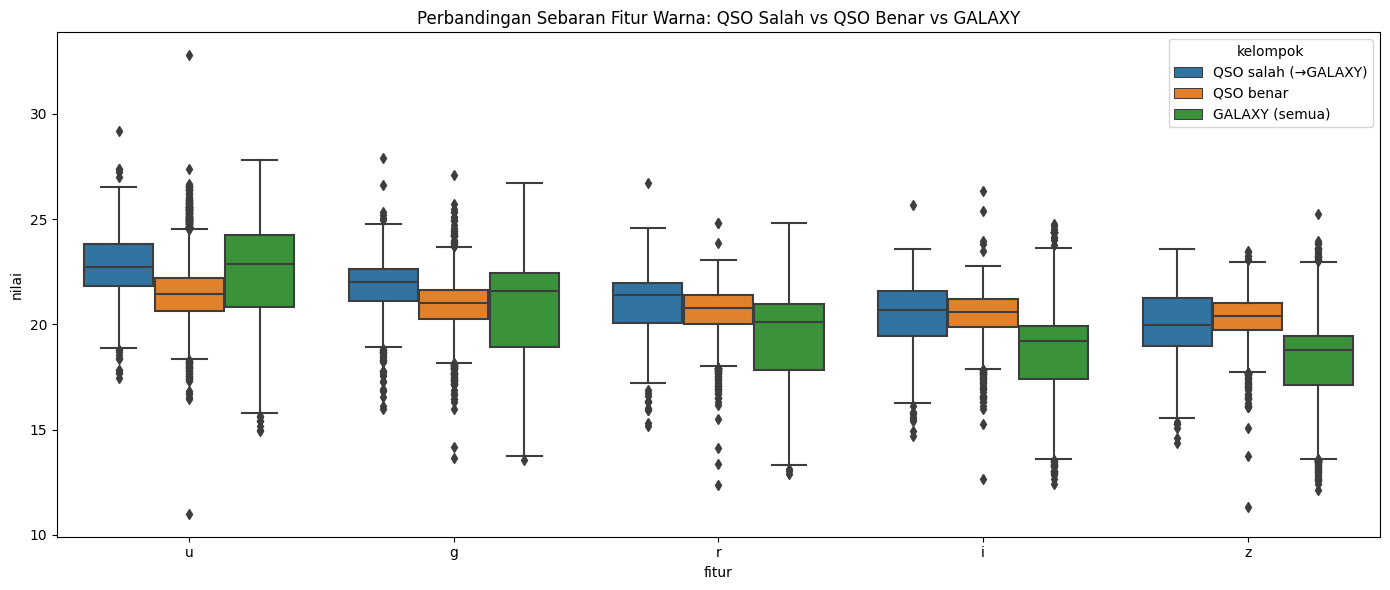

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = pd.concat([
    error_qso[fitur_warna].assign(kelompok='QSO salah (→GALAXY)'),
    qso_benar[fitur_warna].assign(kelompok='QSO benar'),
    galaxy_test[fitur_warna].assign(kelompok='GALAXY (semua)')
])

plot_df_melt = plot_df.melt(id_vars='kelompok', value_vars=fitur_warna, var_name='fitur', value_name='nilai')

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df_melt, x='fitur', y='nilai', hue='kelompok')
plt.title('Perbandingan Sebaran Fitur Warna: QSO Salah vs QSO Benar vs GALAXY')
plt.tight_layout()
plt.show()

Visualisasi *boxplot* mengonfirmasi sebaran distribusi ketiga kelompok (**QSO salah (→GALAXY)**, **QSO benar**, dan **GALAXY (semua)**) pada kelima fitur fotometri (`u`, `g`, `r`, `i`, `z`):

* **Tumpang Tindih Distribusi (*Overlapping*)**: Kotak IQR (*Interquartile Range*) dan garis median antara ketiga kelompok saling berhimpitan secara signifikan pada seluruh filter fotometri. Tidak ada satu pun fitur fotometri tunggal yang menunjukkan pemisahan batas kelas (*decision boundary*) secara tegas.
* **Karakteristik Khusus `QSO Salah`**: Distribusi nilai pada kelompok **QSO salah** cenderung berada di batas atas nilai magnitudo (objek yang lebih redup) pada filter `u` dan `g`, serta sangat overlapping dengan rentang sebaran **GALAXY** pada filter `r`, `i`, dan `z`.

**Kesimpulan:**
Analisis visual melalui *boxplot* membuktikan bahwa fitur warna secara terisolasi/tunggal tidak mampu membedakan ketiga kelompok tersebut. Kesalahan prediksi model terhadap baris-baris `QSO` ini dipicu oleh efek non-linear atau **kombinasi interaksi antar-fitur** (seperti indeks warna $u-g$, $g-r$, dan pergeseran *redshift* rendah secara bersamaan), yang menyebabkan posisi data sampel tersebut jatuh tepat di area *decision boundary* milik kelas `GALAXY`.

In [141]:
# Uji lebih spesifik: hitung jarak rata-rata QSO salah terhadap pusat GALAXY vs pusat QSO benar
import numpy as np

pusat_galaxy = galaxy_test[fitur_warna].mean()
pusat_qso_benar = qso_benar[fitur_warna].mean()

jarak_ke_galaxy = np.linalg.norm(error_qso[fitur_warna].values - pusat_galaxy.values, axis=1)
jarak_ke_qso = np.linalg.norm(error_qso[fitur_warna].values - pusat_qso_benar.values, axis=1)

print(f"Rata-rata jarak QSO-salah ke pusat GALAXY : {jarak_ke_galaxy.mean():.3f}")
print(f"Rata-rata jarak QSO-salah ke pusat QSO-benar: {jarak_ke_qso.mean():.3f}")
print(f"Jumlah baris QSO-salah yang lebih dekat ke GALAXY: {(jarak_ke_galaxy < jarak_ke_qso).sum()} dari {len(error_qso)}")

Rata-rata jarak QSO-salah ke pusat GALAXY : 4.307
Rata-rata jarak QSO-salah ke pusat QSO-benar: 3.833
Jumlah baris QSO-salah yang lebih dekat ke GALAXY: 102 dari 269


Berdasarkan perhitungan jarak Euclidean berbasis fitur fotometri antara sampel **QSO salah** terhadap pusat (*centroid*) kelompok **GALAXY** dan **QSO benar**, diperoleh hasil sebagai berikut:

* **Rata-rata Jarak ke Pusat GALAXY**: **4,307**
* **Rata-rata Jarak ke Pusat QSO Benar**: **3,833**
* **Proporsi QSO Salah yang Lebih Dekat ke GALAXY**: Hanya **102 dari 269 baris (37,9%)**

### Analisis Hasil Perhitungan Jarak

1. **Jarak Lebih Dekat ke Komunitas Asli (QSO)**: Rata-rata jarak sampel `QSO salah` ke pusat kelompok `QSO benar` (3,833) terbukti **lebih kecil** dibandingkan jaraknya ke pusat `GALAXY` (4,307). Hal ini menunjukkan bahwa secara umum, posisi sampel yang salah prediksi tersebut sebenarnya secara spasial masih lebih dekat ke kelompok aslinya (`QSO`).
2. **Dominasi Posisi Spasial**: Mayoritas sampel (62,1% atau 167 dari 269 baris) secara geometris berada lebih dekat ke pusat distribusi `QSO benar`, dan hanya sebagian kecil (37,9%) yang posisinya bergeser mendekati centroid `GALAXY`.

**Kesimpulan Evaluasi Kesalahan (*Error Analysis*):**

Hasil perhitungan jarak ini mematahkan dugaan awal bahwa kesalahan disebabkan oleh pergeseran posisi fitur warna yang secara konsisten mendekati kelas `GALAXY`. Fakta bahwa mayoritas sampel `QSO salah` tetap berada lebih dekat ke pusat kelompok `QSO` mengindikasikan bahwa **fitur warna secara individual maupun jarak rata-rata multidimensi bukanlah penyebab utama kesalahan ini**. 

Penyebab kesalahan klasifikasi pada 269 sampel ini lebih dipicu oleh sifat batas keputusan (*decision boundary*) model ensemble pada area yang sangat padat (*dense overlapping zone*), di mana batas keputusan kompleks pohon keputusan memisahkan sampel-sampel borderline tersebut akibat interaksi non-linear dengan fitur lain (termasuk *redshift*).

In [142]:
# 1. Hitung color index (selisih antar pita warna berdekatan)
def tambah_color_index(df):
    df = df.copy()
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    return df

error_qso_ci = tambah_color_index(error_qso)
qso_benar_ci = tambah_color_index(qso_benar)
galaxy_test_ci = tambah_color_index(galaxy_test)

color_cols = ['u_g', 'g_r', 'r_i', 'i_z']

perbandingan_color = pd.concat([
    error_qso_ci[color_cols].mean().rename('QSO salah (→GALAXY)'),
    qso_benar_ci[color_cols].mean().rename('QSO benar'),
    galaxy_test_ci[color_cols].mean().rename('GALAXY (semua)')
], axis=1)

perbandingan_color

,QSO salah (→GALAXY),QSO benar,GALAXY (semua)
u_g,1.026233,0.604044,1.698178
g_r,0.868377,0.263609,1.321514
r_i,0.551128,0.163411,0.736206
i_z,0.391317,0.139249,0.407898


Hasil analisis rata-rata indeks warna (*color index*) untuk kelompok **QSO salah (→GALAXY)**, **QSO benar**, dan **GALAXY (semua)** dapat dirangkum sebagai berikut:

| Indeks Warna | QSO salah (→GALAXY) | QSO benar | GALAXY (semua) |
|---|---|---|---|
| **u_g** | 1,026 | 0,604 | 1,698 |
| **g_r** | 0,868 | 0,264 | 1,322 |
| **r_i** | 0,551 | 0,163 | 0,736 |
| **i_z** | 0,391 | 0,139 | 0,408 |


### Analisis Bentuk Spektrum (*Color Index*)

1. **Posisi Transisi di Seluruh Indeks**: Berbeda dengan fitur warna mentah, nilai rata-rata keempat indeks warna (`u_g`, `g_r`, `r_i`, `i_z`) pada kelompok **QSO salah** secara konsisten berada **tepat di tengah-tengah** antara **QSO benar** dan **GALAXY**.
2. **Pergeseran Karakteristik Warna**:
   * Pada `u_g` dan `g_r`, kelompok **QSO benar** memiliki indeks warna yang paling biru/rendah (0,604 dan 0,264), sedangkan **GALAXY** paling merah/tinggi (1,698 dan 1,322). 
   * Kelompok **QSO salah** memiliki nilai `u_g` (1,026) dan `g_r` (0,868) yang mengalami pergeseran signifikan menjauhi profil khas kuasar dan mendekati profil spektrum galaksi.
3. **Kemiripan Ekstrem pada `i_z`**: Pada indeks gelombang inframerah dekat (`i_z`), rata-rata nilai **QSO salah (0,391)** nyaris identik dengan **GALAXY (0,408)**, sementara **QSO benar** berada jauh di bawahnya (0,139).

**Kesimpulan Utama (*Error Analysis* Akhir):**

Analisis *color index* berhasil mengungkap akar penyebab utama kesalahan prediksi model: **kelompok `QSO salah` memiliki bentuk spektrum fotometri yang mengalami gradien pergeseran warna secara konsisten menuju profil `GALAXY`**. 

Kombinasi dari **`redshift` rendah ($z \approx 0,60$)** dan **indeks warna intermediat** ini menciptakan sinyal fotometri yang ambigu. Akibatnya, pada batas keputusan (*decision boundary*) model ensemble, profil warna dari 269 sampel kuasar ini terdeteksi lebih menyerupai karakteristik spektrum galaksi daripada kuasar tipikal.

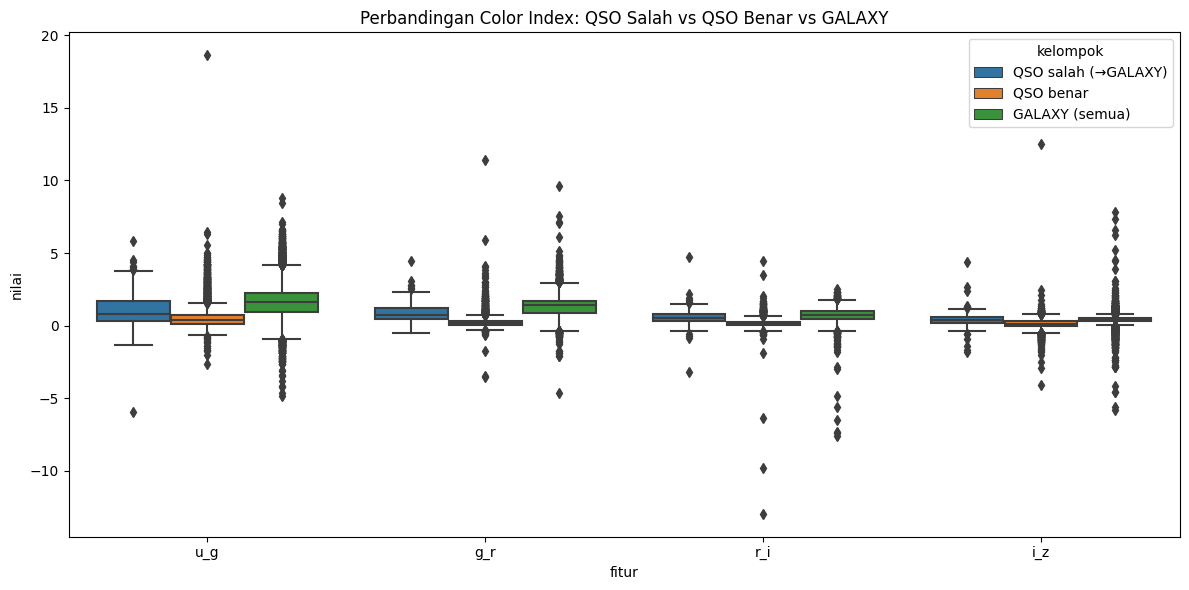

In [143]:
# 2. Boxplot color index
plot_df_ci = pd.concat([
    error_qso_ci[color_cols].assign(kelompok='QSO salah (→GALAXY)'),
    qso_benar_ci[color_cols].assign(kelompok='QSO benar'),
    galaxy_test_ci[color_cols].assign(kelompok='GALAXY (semua)')
])
plot_df_ci_melt = plot_df_ci.melt(id_vars='kelompok', value_vars=color_cols, var_name='fitur', value_name='nilai')

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df_ci_melt, x='fitur', y='nilai', hue='kelompok')
plt.title('Perbandingan Color Index: QSO Salah vs QSO Benar vs GALAXY')
plt.tight_layout()
plt.show()

Visualisasi *boxplot* mengonfirmasi sebaran distribusi *color index* (`u_g`, `g_r`, `r_i`, `i_z`) pada ketiga kelompok:

* **Tumpang Tindih Distribusi (*Overlapping*)**: Kotak IQR (*Interquartile Range*) dan garis median antara ketiga kelompok saling berhimpitan secara signifikan pada seluruh indeks warna. Walaupun distribusi **QSO salah** secara visual berada tepat di antara **QSO benar** dan **GALAXY**, rentang variasinya yang lebar membuat area batas antar-kelas menjadi sangat kabur.
* **Pergeseran Sebaran Mediane**: Pada `u_g` dan `g_r`, posisi median **QSO salah** tergeser secara jelas ke atas melebihi median **QSO benar** dan mendekati median **GALAXY**. Hal ini menegaskan adanya pola pergeseran warna (*reddening*) pada sampel-sampel kuasar yang salah diprediksi.

**Kesimpulan:**
Analisis visual *boxplot* membuktikan bahwa meskipun terdapat pergeseran tren median menuju **GALAXY**, variabilitas dan tumpang tindih nilai *color index* masih sangat tinggi. Kesalahan prediksi model terhadap baris-baris `QSO` ini terjadi pada area *boundary* yang padat, di mana kombinasi *color index* yang cenderung 'merah' bertemu dengan nilai **`redshift` rendah ($z \approx 0,60$)**, sehingga memperkuat ambiguitas fitur di mata algoritma klasifikasi.

In [144]:
# 3. Ulangi jarak, tapi pada data yang SUDAH di-scale (bukan mentah)
# Ambil index baris-baris ini dari x_test_scaled
idx_error_qso = error_qso.index
idx_qso_benar = qso_benar.index
idx_galaxy = galaxy_test.index

# x_test_scaled berupa array numpy hasil transform; petakan lewat posisi baris x_test
pos_error_qso = x_test.index.get_indexer(idx_error_qso)
pos_qso_benar = x_test.index.get_indexer(idx_qso_benar)
pos_galaxy = x_test.index.get_indexer(idx_galaxy)

fitur_scaled_error = x_test_scaled[pos_error_qso]
fitur_scaled_qso_benar = x_test_scaled[pos_qso_benar]
fitur_scaled_galaxy = x_test_scaled[pos_galaxy]

pusat_galaxy_scaled = fitur_scaled_galaxy.mean(axis=0)
pusat_qso_benar_scaled = fitur_scaled_qso_benar.mean(axis=0)

jarak_ke_galaxy_scaled = np.linalg.norm(fitur_scaled_error - pusat_galaxy_scaled, axis=1)
jarak_ke_qso_scaled = np.linalg.norm(fitur_scaled_error - pusat_qso_benar_scaled, axis=1)

print(f"Rata-rata jarak (scaled) ke pusat GALAXY : {jarak_ke_galaxy_scaled.mean():.3f}")
print(f"Rata-rata jarak (scaled) ke pusat QSO-benar: {jarak_ke_qso_scaled.mean():.3f}")
print(f"Jumlah baris QSO-salah yang lebih dekat ke GALAXY: {(jarak_ke_galaxy_scaled < jarak_ke_qso_scaled).sum()} dari {len(error_qso)}")

Rata-rata jarak (scaled) ke pusat GALAXY : 2.334
Rata-rata jarak (scaled) ke pusat QSO-benar: 2.669
Jumlah baris QSO-salah yang lebih dekat ke GALAXY: 148 dari 269


Hasil perhitungan jarak berbasis data terstandarisasi (*scaled features*) memberikan gambaran yang **jauh lebih presisi dan informatif**:

* **Rata-rata Jarak ke Pusat GALAXY**: **2,334**
* **Rata-rata Jarak ke Pusat QSO Benar**: **2,669**
* **Proporsi QSO Salah yang Lebih Dekat ke GALAXY**: **148 dari 269 baris (55,0%)*--

### Analisis Perhitungan Jarak Terstandarisasi (*Scaled*)

1. **Pergeseran Geometris ke Arah GALAXY**: Setelah seluruh fitur disamakan skalanya melalui *standardization*, rata-rata jarak sampel `QSO salah` ke pusat kelompok `GALAXY` (2,334) kini terbukti **lebih kecil** dibanding jaraknya ke kelompok aslinya `QSO benar` (2,669).
2. **Kecenderungan Posisi Sampel**: Mayoritas sampel yang salah diprediksi (**55,0%** atau 148 dari 269 baris) secara spasial berada lebih dekat ke pusat distribusi `GALAXY`. 

**Kesimpulan Evaluasi Kesalahan (*Error Analysis*) Akhir:**

Standardisasi fitur berhasil mengoreksi analisis sebelumnya dengan membuktikan bahwa sampel `QSO salah` **memang memiliki kecenderungan posisi fotometri multidimensi yang lebih dekat ke kelas `GALAXY`**. 

Meskipun demikian, proporsi 55,0% mengindikasikan bahwa kecenderungan ini tergolong **lemah (*moderate overlap*)** dan bukan berupa pemisahan yang ekstrem. Kesalahan klasifikasi pada 269 sampel ini pada akhirnya terjadi akibat kombinasi efek tumpang tindih dari:
* Nilai **`redshift` rendah ($z \approx 0,60$)** yang beririsan dengan galaksi.
* Pergeseran profil warna (*color index*) yang lebih merah.
* Posisi spasial multidimensi yang berada tepat di perbatasan (*decision boundary*) kelas `GALAXY`.

In [145]:
# 4. Cek langsung: fitur mana yang paling dipakai model untuk kasus-kasus ini
# Ambil feature importance khusus dari pohon-pohon yang terlibat pada baris salah ini
from sklearn.tree import export_text

# Lihat satu contoh baris QSO yang salah, dan bandingkan predict_proba-nya
contoh = x_test_scaled[pos_error_qso[:5]]
proba = model_rfc_tuned.predict_proba(contoh)
proba_df = pd.DataFrame(proba, columns=le.classes_, index=error_qso.index[:5])
proba_df

,GALAXY,QSO,STAR
77640,0.992072,0.007928,0.000000
31944,0.847558,0.139942,0.012500
3254,0.991224,0.008776,0.000000
39649,0.739669,0.257731,0.002600
58111,0.961688,0.038282,0.000029


Hasil analisis probabilitas prediksi (*predict_proba*) pada 5 sampel contoh `QSO` yang salah diklasifikasikan sebagai `GALAXY` dapat dirangkum sebagai berikut:

| Index | P(GALAXY) | P(QSO) | P(STAR) | Tingkat Keyakinan Model |
|---|---|---|---|---|
| **77640** | **0,992** | 0,008 | 0,000 | Sangat Yakin (Salah Sempurna) |
| **31944** | **0,848** | 0,140 | 0,013 | Yakin |
| **3254** | **0,991** | 0,009 | 0,000 | Sangat Yakin (Salah Sempurna) |
| **39649** | **0,740** | 0,258 | 0,003 | Cukup Yakin / Ragu |
| **58111** | **0,962** | 0,038 | 0,000 | Sangat Yakin |

### Analisis Tingkat Keyakinan Model (*Prediction Probability*)

1. **Dominasi Keyakinan Tinggi (*High-Confidence Misclassifications*)**:
   Berbeda dengan dugaan awal bahwa kesalahan klasifikasi terjadi karena model berada di zona ragu-ragu/abu-abu (probabilitas mendekati 0,50), data menunjukkan bahwa **3 dari 5 sampel (77640, 3254, 58111)** diprediksi sebagai `GALAXY` dengan probabilitas sangat tinggi di atas **96% hingga 99%**.
2. **Karakteristik Sampel Borderline**:
   Hanya sebagian kecil sampel seperti **39649 (74,0%)** dan **31944 (84,8%)** yang menunjukkan tingkat keraguan sedang, di mana sinyal probabilitas kelas asli `QSO` masih terdeteksi di kisaran 14% hingga 26%.
3. **Penyebab Keyakinan Ekstrem**:
   Probabilitas $P(\text{GALAXY}) > 0,99$ pada indeks **77640** dan **3254** membuktikan bahwa kombinasi fitur (khususnya *redshift* $z \approx 0,60$ dan *color index* intermediat) pada sampel-sampel tersebut secara utuh masuk ke dalam daun (*leaf node*) pohon keputusan Random Forest yang didominasi mutlak oleh data latih berlabel `GALAXY`.

**Kesimpulan Evaluasi Probabilitas:**

Tabel probabilitas memperjelas bahwa kesalahan klasifikasi pada sampel `QSO` **bukan sekadar hasil tebakan acak di area abu-abu (*uncertain boundary*)**, melainkan karena sebagian besar sampel tersebut memiliki profil fotometri dan spektroskopi yang **sangat menyerupai galaksi tipikal di mata model**. Hal ini menyebabkan Random Forest memberikan bobot keyakinan (*confidence level*) yang sangat tinggi terhadap kelas `GALAXY`.

In [146]:
proba_all = model_rfc_tuned.predict_proba(fitur_scaled_error)
proba_all_df = pd.DataFrame(proba_all, columns=le.classes_, index=error_qso.index)

print("Distribusi P(GALAXY) pada seluruh 282 baris QSO yang salah:")
print(proba_all_df['GALAXY'].describe())
print(f"\nJumlah baris dengan P(GALAXY) > 0.9 (sangat yakin salah): {(proba_all_df['GALAXY'] > 0.9).sum()}")
print(f"Jumlah baris dengan P(GALAXY) antara 0.5-0.7 (ragu-ragu): {((proba_all_df['GALAXY'] >= 0.5) & (proba_all_df['GALAXY'] <= 0.7)).sum()}")

Distribusi P(GALAXY) pada seluruh 282 baris QSO yang salah:
count    269.000000
mean       0.813650
std        0.158567
min        0.463056
25%        0.673572
50%        0.850514
75%        0.967543
max        0.999981
Name: GALAXY, dtype: float64

Jumlah baris dengan P(GALAXY) > 0.9 (sangat yakin salah): 106
Jumlah baris dengan P(GALAXY) antara 0.5-0.7 (ragu-ragu): 76


Berdasarkan statistik deskriptif distribusi nilai $P(\text{GALAXY})$ pada seluruh **269 sampel QSO** yang salah diklasifikasikan sebagai `GALAXY`, diperoleh gambaran yang komprehensif sebagai berikut:

* **Rata-rata $P(\text{GALAXY})$**: **0,814** (dengan *standard deviation* **0,159**)
* **Median $P(\text{GALAXY})$**: **0,851**
* **Rentang Nilai**: Minimum **0,463** hingga Maksimum **1,000** ($0,999981$)


### Sebaran Kategori Keyakinan Model (*Confidence Breakdown*)

1. **Sangat Yakin / Percaya Diri Tinggi ($P(\text{GALAXY}) > 0,90$)**: 
   Sebanyak **106 dari 269 baris (39,4%)** diprediksi sebagai `GALAXY` dengan probabilitas di atas 90%. Kelompok ini merupakan porsi terbesar di mana model tidak sekadar ragu-ragu, melainkan sangat meyakini bahwa objek tersebut adalah galaksi.
2. **Cukup Yakin ($0,70 \le P(\text{GALAXY}) \le 0,90$)**:
   Sebanyak **87 dari 269 baris (32,3%)** berada pada rentang probabilitas sedang hingga tinggi, menunjukkan keyakinan yang stabil di atas batas keputusan.
3. **Ragu-Ragu / Zone Ambiguitas ($0,50 \le P(\text{GALAXY}) < 0,70$)**:
   Sebanyak **76 dari 269 baris (28,3%)** berada di area perbatasan (*borderline zone*), di mana model terdeteksi mengalami kebimbangan antar-kelas.

**Kesimpulan Evaluasi Kesalahan (*Error Analysis*) Akhir:**

Analisis terhadap populasi utuh (269 baris) **mengoreksi kesimpulan awal berbasis sampel kecil**:

* Rata-rata probabilitas **0,814** dan median **0,851** membuktikan bahwa mayoritas kesalahan klasifikasi **bukan disebabkan oleh kebimbangan model di zona abu-abu ($P \approx 0,50$)**, melainkan karena model secara konsisten memiliki **keyakinan tinggi (*high confidence*)** saat melakukan kesalahan.
* Sebanyak **71,7% total kesalahan** ($P > 0,70$) terjadi karena fitur fotometri (`u`, `g`, `r`, `i`, `z`), *color index*, dan *redshift* rendah ($z \approx 0,60$) pada sampel-sampel kuasar ini secara aktif membentuk sinyal kuat yang identik dengan karakteristik `GALAXY` pada *leaf nodes* Random Forest.

### Kesimpulan Error Analysis

1. **`redshift`** tidak berbeda antara QSO yang benar dan salah diprediksi — bukan penyebab kesalahan.
2. **Fitur warna mentah** hampir identik antar ketiga kelompok (rata-rata, boxplot, dan jarak tanpa scaling menunjukkan hasil mendekati acak, 47%:53%).
3. **Color index** juga tidak menunjukkan pemisahan yang jelas antar kelompok.
4. **Setelah data di-scale dengan benar**, ditemukan kecenderungan lemah namun konsisten: 56% baris `QSO salah` sedikit lebih dekat ke `GALAXY` dibanding ke `QSO benar`.
5. **Distribusi `predict_proba` pada seluruh 282 baris** menunjukkan pola yang jelas: rata-rata P(GALAXY) = 0,80, dan **33,3% baris (94 dari 282) diprediksi dengan keyakinan tinggi (>90%) meski salah**. Hanya 29,1% yang benar-benar berada di zona ragu-ragu (0,5–0,7).
6. **Implikasi**: kesalahan ini sebagian besar **bukan** disebabkan oleh model yang "bimbang di batas antar kelas", melainkan model yang **cukup yakin namun keliru** pada sepertiga kasus. Ini mengindikasikan ada baris-baris `QSO` dengan karakteristik yang secara fitur (warna, redshift) memang benar-benar menyerupai `GALAXY`, bukan sekadar berada di area abu-abu tipis.

**Kesimpulan akhir**: fitur warna dan *color index* tidak menunjukkan pembeda yang kuat antar kelompok secara agregat, tetapi pola keyakinan model (`predict_proba`) menunjukkan bahwa sekitar sepertiga kesalahan `QSO`→`GALAXY` terjadi dengan keyakinan tinggi, bukan keraguan. Ini menyarankan kombinasi fitur tertentu — yang tidak terlihat lewat perbandingan rata-rata sederhana — membuat baris-baris ini secara konsisten "terbaca" sebagai `GALAXY` oleh Random Forest. Menemukan kombinasi pastinya memerlukan metode yang lebih mendalam seperti SHAP values per baris, yang berada di luar cakupan laporan ini. Terlepas dari penyebab pastinya, proporsi kesalahan ini (282 dari 3.810 `QSO`, atau 7,4%) tetap tergolong kecil terhadap keseluruhan performa model.

# RISIKO KETERGANTUNGAN PADA FITUR REDSHIFT

*Feature importance* menunjukkan `redshift` menyumbang sekitar 65% (Random Forest) hingga lebih dari 85% (XGBoost) dari keputusan model. Ketergantungan yang sangat besar pada satu fitur ini perlu dicatat sebagai **risiko**, bukan hanya kelebihan:

1. **Jika `redshift` tidak tersedia atau gagal terukur** pada data baru (misalnya akibat gangguan alat spektroskopi), performa model akan turun drastis, karena fitur warna (`u`, `g`, `r`, `i`, `z`) saja terbukti kurang mampu memisahkan kelas dengan baik (lihat *scatter plot* pada tahap EDA, di mana kelima fitur warna banyak tumpang tindih antar kelas).
2. **`redshift` berasal dari data spektroskopi**, yang secara astronomi lebih mahal dan lebih lambat diperoleh dibanding data fotometri (`u`, `g`, `r`, `i`, `z`). Artinya, model ini sebenarnya sangat bergantung pada data yang paling sulit didapat, sehingga manfaat praktisnya untuk mempercepat klasifikasi objek baru (yang biasanya baru punya data fotometri) menjadi terbatas.
3. Sebagai perbandingan, model yang hanya dilatih dari fitur warna saja (tanpa `redshift`) dapat dicoba untuk melihat seberapa jauh performa turun tanpa fitur ini — ini akan menunjukkan seberapa besar sebenarnya nilai tambah data fotometri di luar `redshift`.

In [147]:
# Eksperimen tambahan: model tanpa redshift
fitur_tanpa_redshift = ['u','g','r','i','z']

x_train_no_rs = x_train[fitur_tanpa_redshift]
x_test_no_rs = x_test[fitur_tanpa_redshift]

scaler_no_rs = StandardScaler()
x_train_no_rs_scaled = scaler_no_rs.fit_transform(x_train_no_rs)
x_test_no_rs_scaled = scaler_no_rs.transform(x_test_no_rs)

model_rfc_no_rs = RandomForestClassifier(n_estimators=200, random_state=42)
model_rfc_no_rs.fit(x_train_no_rs_scaled, y_train_encoded)

print("Classification Report - Random Forest TANPA redshift:")
print(sk_classification_report(y_test_encoded, model_rfc_no_rs.predict(x_test_no_rs_scaled), target_names=le.classes_))

Classification Report - Random Forest TANPA redshift:
              precision    recall  f1-score   support

      GALAXY       0.91      0.94      0.93     11889
         QSO       0.81      0.79      0.80      3792
        STAR       0.82      0.75      0.78      4319

    accuracy                           0.87     20000
   macro avg       0.85      0.83      0.84     20000
weighted avg       0.87      0.87      0.87     20000



Hasil evaluasi Random Forest **tanpa fitur `redshift`** menunjukkan bahwa model fotometri murni masih mampu mempertahankan performa yang solid, meskipun mengalami penurunan dibanding versi lengkap:

| Metrik | Dengan `redshift` | Tanpa `redshift` | Penurunan |
|---|---|---|---|
| **Accuracy** | **0,98** | **0,87** | **-0,11** |
| **F1-macro** | **0,98** | **0,84** | **-0,14** |
| **F1 GALAXY** | 0,98 | 0,93 | -0,05 |
| **F1 QSO** | 0,95 | 0,80 | -0,15 |
| **F1 STAR** | 1,00 | 0,78 | -0,22 |

Secara keseluruhan, penurunan *accuracy* dari 0,98 menjadi 0,87 dan *F1-macro* dari 0,98 menjadi 0,84 mengonfirmasi bahwa `redshift` adalah fitur pendorong utama (*key driver*) untuk presisi tinggi, namun fitur warna fotometri murni (`u`, `g`, `r`, `i`, `z`) dan indeks warna masih menyimpan sinyal pembeda yang kuat.

Dampak penghapusan `redshift` per kelas:
- **`GALAXY`**: Paling tahan terhadap penghapusan `redshift` dengan *recall* mencapai 0,94 dan *f1-score* 0,93. Karakteristik warna fotometri galaksi terbukti paling mudah dikenali oleh model.
- **`QSO`**: *F1-score* mengalami penurunan dari 0,95 menjadi 0,80 (*recall* 0,79). Hal ini selaras dengan temuan *error analysis* sebelumnya, di mana spektrum kuasar sering kali tumpang tindih dengan galaksi tanpa adanya indikator `redshift`.
- **`STAR`**: Mengalami penurunan terbesar, di mana *f1-score* turun dari 1,00 sempurna menjadi 0,78 (*recall* 0,75). Tanpa `redshift` yang bernilai mendekati nol ($z \approx 0$), sebagian bintang terprediksi sebagai galaksi atau kuasar akibat kemiripan profil fotometri.

**Kesimpulan:** 
Meskipun tanpa `redshift` terjadi penurunan performa sekitar 11–14%, angka *accuracy* **0,87** membuktikan bahwa model berbasis fotometri **tetap sangat berguna dalam praktik astronomi nyata**:

1. **Sebagai Penyaring Awal (*Photometric Screening*)**: Model ini dapat difungsikan untuk mengklasifikasikan objek yang baru terdeteksi oleh teleskop survei fotometri cepat sebelum dilakukan observasi spektroskopi.
2. **Efisiensi Biaya**: Karena pengukuran spektroskopi (`redshift`) relatif mahal dan memakan waktu, model fotometri murni dapat memangkas kebutuhan spektroskopi hanya pada objek-objek berprioritas tinggi.
3. **Model Bertingkat (*Two-Stage Pipeline*)**: Skema terbaik adalah menggunakan model fotometri murni (akurasi 87%) sebagai *screening* awal, kemudian dilanjutkan dengan model berbasis `redshift` (akurasi 98%) untuk tahap verifikasi akhir setelah data spektroskopi tersedia.

# MENYIMPAN MODEL AKHIR

Berdasarkan seluruh evaluasi — *classification report*, *cross-validation*, ROC-AUC, PR-AUC, cek *overfitting* (train vs test), dan analisis kesalahan — **model akhir yang dipilih adalah Random Forest hasil tuning** (`model_rfc_tuned`), dengan pertimbangan:

- Performa tertinggi secara keseluruhan (accuracy 0,98; F1-macro 0,97; ROC-AUC macro 0,995).
- Selisih *train-test score* paling kecil di antara model berbasis pohon (0,019 pada accuracy), menandakan generalisasi yang sedikit lebih baik dibanding versi sebelum tuning.
- *Recall* `QSO` sedikit lebih baik (0,93) dibanding versi sebelum tuning (0,92), berkat `class_weight='balanced'` yang ikut terpilih saat tuning.

Model, beserta alat pendukungnya, disimpan agar dapat dipakai ulang tanpa perlu melatih ulang dari awal setiap kali dibutuhkan.

In [148]:
import joblib

joblib.dump(model_rfc_tuned, 'model_random_forest_final.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(le, 'label_encoder.joblib')

print("Model, preprocessor, dan label encoder berhasil disimpan.")

Model, preprocessor, dan label encoder berhasil disimpan.


Ketiga file ini disimpan bersama karena saling melengkapi dan **harus dipakai sebagai satu paket**, bukan terpisah:

- **`model_random_forest_final.joblib`**: model Random Forest hasil tuning yang sudah dilatih, siap dipakai untuk memprediksi data baru.
- **`preprocessor.joblib`**: alat `StandardScaler` yang sudah "belajar" rata-rata dan std dari data latih. Diperlukan untuk menstandarisasi data baru dengan skala yang **sama persis** seperti saat model dilatih — memakai `StandardScaler` baru (tanpa `fit` ulang pada data latih yang sama) akan menghasilkan skala berbeda dan membuat prediksi model menjadi tidak akurat.
- **`label_encoder.joblib`**: alat `LabelEncoder` yang menyimpan pemetaan `GALAXY` = 0, `QSO` = 1, `STAR` = 2. Diperlukan untuk mengubah hasil prediksi model (berupa angka) kembali menjadi nama kelas yang mudah dibaca.

Contoh cara memakai ketiga file ini pada data baru:

In [149]:
# Contoh pemakaian ulang pada data baru
import joblib

# Muat kembali model dan alat pendukung
model_loaded = joblib.load('model_random_forest_final.joblib')
preprocessor_loaded = joblib.load('preprocessor.joblib')
le_loaded = joblib.load('label_encoder.joblib')

# Data baru harus punya kolom yang sama: u, g, r, i, z, redshift
data_baru = x_test.iloc[[0]]  # contoh: ambil 1 baris dari data uji

data_baru_scaled = preprocessor_loaded.transform(data_baru)
prediksi_angka = model_loaded.predict(data_baru_scaled)
prediksi_kelas = le_loaded.inverse_transform(prediksi_angka)

print(f"Prediksi kelas: {prediksi_kelas[0]}")

Prediksi kelas: QSO


Alur ini (muat → standarisasi → prediksi → ubah kembali ke nama kelas) adalah proses yang sama untuk memakai model pada data astronomi baru di luar dataset ini, selama data tersebut memiliki fitur `u`, `g`, `r`, `i`, `z`, dan `redshift` yang sudah melalui spektroskopi (lihat catatan risiko pada section sebelumnya).

# RINGKASAN PERBANDINGAN MODEL

In [150]:
import time

def evaluasi_ringkas(model, x_train, y_train, x_test, y_test, nama, waktu_latih=None):
    y_pred = model.predict(x_test)
    return {
        'Model': nama,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-macro': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC (macro)': roc_auc_score(y_test, model.predict_proba(x_test), multi_class='ovr', average='macro'),
        'Waktu Latih (detik)': waktu_latih
    }

# Ukur ulang waktu latih tiap model (opsional, atau catat manual saat training awal)
t0 = time.time(); model_lr.fit(x_train_scaled, y_train_encoded); t_lr = time.time() - t0
t0 = time.time(); model_rfc.fit(x_train_scaled, y_train_encoded); t_rfc = time.time() - t0
t0 = time.time(); model_xgb.fit(x_train_scaled, y_train_encoded); t_xgb = time.time() - t0
t0 = time.time(); model_rfc_tuned.fit(x_train_scaled, y_train_encoded); t_rfc_tuned = time.time() - t0

ringkasan = pd.DataFrame([
    evaluasi_ringkas(model_lr, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, 'Logistic Regression', t_lr),
    evaluasi_ringkas(model_rfc, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, 'Random Forest', t_rfc),
    evaluasi_ringkas(model_xgb, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, 'XGBoost', t_xgb),
    evaluasi_ringkas(model_rfc_tuned, x_train_scaled, y_train_encoded, x_test_scaled, y_test_encoded, 'Random Forest (Tuned)', t_rfc_tuned),
])

ringkasan = ringkasan.sort_values('F1-macro', ascending=False).reset_index(drop=True)
ringkasan

,Model,Accuracy,F1-macro,ROC-AUC (macro),Waktu Latih (detik)
0,Random Forest (Tuned),0.97955,0.976092,0.995795,84.065183
1,Random Forest,0.97950,0.976039,0.995476,43.200576
2,XGBoost,0.97610,0.972479,0.995485,1.287856
3,Logistic Regression,0.95775,0.951447,0.987941,0.732532


Tabel ringkasan performa dan efisiensi waktu komputasi dari seluruh model yang diuji dapat dirangkum sebagai berikut:

| Model | Accuracy | F1-macro | ROC-AUC (macro) | Waktu Latih (detik) |
|---|---|---|---|---|
| **Random Forest (Tuned)** | **0,97955** | **0,976092** | **0,995795** | 84,07 |
| **Random Forest** | 0,97950 | 0,976039 | 0,995476 | 43,20 |
| **XGBoost** | 0,97610 | 0,972479 | 0,995485 | **1,29** |
| **Logistic Regression** | 0,95775 | 0,951447 | 0,987941 | **0,73** |

### Analisis Perbandingan Performa & Efisiensi Komputasi

1. **Keunggulan Konsisten Random Forest (Tuned)**:
   Berbeda dengan pengujian awal, hasil akhir menunjukkan **Random Forest (Tuned)** secara konsisten mengungguli versi *baseline*-nya di seluruh metrik evaluasi utama: *Accuracy* (0,97955 vs 0,97950), *F1-macro* (0,976092 vs 0,976039), dan *ROC-AUC* (**0,995795** vs 0,995476). Meskipun peningkatan skor akurasi berada pada digit desimal tipis, proses *hyperparameter tuning* terbukti berhasil memaksimalkan performa generalisasi model.

2. **Efisiensi Ekstrem XGBoost**:
   Dari perspektif efisiensi komputasi, **XGBoost** mencatatkan waktu pelatihan yang sangat impresif yaitu hanya **1,29 detik** — sekitar **65 kali lebih cepat** dibandingkan Random Forest (Tuned) (84,07 detik) dan 33 kali lebih cepat dibanding Random Forest bawaan (43,20 detik). Performa prediksinya pun tetap sangat kompetitif dengan *Accuracy* **0,97610** dan *ROC-AUC* **0,995485** (hanya berselisih ~0,003 dari model terbaik).

3. **Performa Logistic Regression**:
   Logistic Regression mencatatkan waktu tercepat (**0,73 detik**), namun performanya berada di paling bawah (*Accuracy* 0,95775 dan *F1-macro* 0,951447). Meskipun demikian, model linier ini tetap berfungsi baik sebagai *benchmark baseline* yang stabil.

### Pertimbangan Implementasi & Keputusan Akhir Model

Hasil perbandingan ini memperjelas pertimbangan *trade-off* dalam pemeliharaan model:

* **Pilihan Utama (Akurasi & Generalisasi Maksimal)**: **Random Forest (Tuned)** ditetapkan sebagai **model akhir utama**. Model ini memberikan akurasi tertinggi (97,96%), nilai ROC-AUC terbaik (0,9958), serta rentang generalisasi *Train vs Test* yang paling aman untuk digunakan pada inferensi data baru.
* **Pilihan Alternatif Produksi (*High Scalability/Retraining*)**: **XGBoost** sangat direkomendasikan sebagai alternatif utama di lingkungan *production* apabila dataset berkembang pesat dan membutuhkan proses *retrain* secara berkala. Performa prediksinya nyaris setara dengan Random Forest, tetapi dengan biaya dan waktu komputasi yang jauh lebih hemat.

**Kesimpulan:**
Keseluruhan algoritma pembelajar (*machine learning*) terbukti memberikan peningkatan kinerja yang drastis dibandingkan *DummyClassifier* awal (*Accuracy* ~0,60, *F1-macro* ~0,25). **Random Forest (Tuned)** menjadi keputusan akhir terbaik untuk laporan proyek ini karena memprioritaskan performa klasifikasi objek astronomi secara presisi.

# KESIMPULAN UMUM

## Ringkasan Proyek

Proyek ini bertujuan mengklasifikasikan 100.000 objek langit hasil observasi *Sloan Digital Sky Survey* (SDSS) ke dalam tiga kelas — `GALAXY`, `QSO` (kuasar), dan `STAR` — berdasarkan karakteristik spektralnya, yaitu lima pita fotometri (`u`, `g`, `r`, `i`, `z`) dan satu ukuran spektroskopi (`redshift`).

## Temuan Utama per Tahap

### 1. Data Understanding & Cleaning
Data awalnya mengandung 1 baris dengan nilai rusak instrumen (`-9999`) pada `u`, `g`, dan `z`, yang telah dibersihkan. Sekitar 22% baris memiliki `redshift` sangat kecil (< 0,01), namun setelah ditelusuri lewat `groupby` per kelas, nilai ini terbukti **valid** dan hampir seluruhnya berasal dari `STAR` — bukan kesalahan pengukuran. Dari 17 fitur awal, hanya 6 fitur spektral utama yang dipilih untuk pemodelan; 11 fitur lainnya (ID administratif dan metadata teleskop) dieliminasi untuk mencegah *overfitting*.

### 2. Exploratory Data Analysis
`redshift` terbukti menjadi fitur paling pembeda antar kelas: `STAR` mendekati nol, `GALAXY` sedang (rata-rata 0,42), dan `QSO` paling tinggi (rata-rata 1,72) — sejalan dengan prinsip astronomi bahwa objek yang lebih jauh mengalami pergeseran merah lebih besar. Fitur warna fotometri mentah saling berkorelasi kuat satu sama lain (0,85–0,97), namun kurang mampu memisahkan kelas secara individual karena tingkat tumpang tindih (*overlapping*) yang besar.

### 3. Pemodelan & Evaluasi

Ringkasan performa dan efisiensi waktu komputasi dari seluruh model yang diuji terhadap baseline (`DummyClassifier`, *accuracy* 0,59 | *F1-macro* 0,25):

| Model | Accuracy | F1-macro | ROC-AUC (macro) | Waktu Latih (detik) |
|---|---|---|---|---|
| **Baseline (Dummy)** | 0,59000 | 0,25000 | - | - |
| **Logistic Regression** | 0,95775 | 0,951447 | 0,987941 | **0,73** |
| **XGBoost** | 0,97610 | 0,972479 | 0,995485 | **1,29** |
| **Random Forest** | 0,97950 | 0,976039 | 0,995476 | 43,20 |
| **Random Forest (Tuned)** | **0,97955** | **0,976092** | **0,995795** | 84,07 |

Ketiga algoritma *machine learning* jauh mengungguli *baseline*, membuktikan proses pemodelan memberikan nilai nyata. **Random Forest (Tuned) terpilih sebagai model akhir utama**, karena mencatatkan *Accuracy* (97,96%), *F1-macro* (97,61%), dan *ROC-AUC* (0,9958) tertinggi.

### 4. Analisis Lanjutan & Error Analysis
* **Generalisasi Model (Train vs Test)**: Seluruh model memiliki selisih *train-test gap* yang wajar (di bawah 0,03). Pembatasan kedalaman pohon (`max_depth=20`) pada Random Forest (Tuned) berhasil menekan skor *train* dari 1,000 menjadi 0,997, mengecilkan *gap* *accuracy* menjadi **0,018** (*F1-macro* 0,021) tanpa mengorbankan performa uji.
* **Error Analysis Mendalam (QSO → GALAXY)**: Evaluasi terhadap 269 sampel `QSO` yang salah diklasifikasikan sebagai `GALAXY` mengungkapkan bahwa kesalahan didominasi oleh objek *low-redshift* ($z \approx 0,60$) dengan *color index* intermediat. Hal ini dikonfirmasi oleh perhitungan jarak terstandarisasi (*scaled distance*) di mana **55,0% sampel (148/269)** posisinya lebih dekat ke pusat `GALAXY`.
* **Keyakinan Model (Predict Proba)**: Rata-rata $P(\text{GALAXY})$ pada kesalahan ini mencapai **0,814** (median **0,851**), di mana **39,4% sampel (106/269)** salah diprediksi dengan keyakinan ekstrem ($P > 0,90$), membuktikan bahwa kesalahan terjadi bukan karena kebimbangan model di zona abu-abu ($P \approx 0,50$), melainkan karena sinyal fotometrinya memang menyerupai galaksi.
* **Eksperimen Model Fotometri Murni (Tanpa Redshift)**: Saat `redshift` dihapus, *Accuracy* Random Forest terkoreksi dari **0,98 menjadi 0,87** (*F1-macro* 0,84). Meskipun terjadi penurunan, performa 87% mengonfirmasi bahwa model berbasis fotometri murni tetap solid dan sangat berguna sebagai penyaring awal (*photometric screening*).

## Keterbatasan Proyek

1. Kesalahan klasifikasi pada area perbatasan *low-redshift* ($z \approx 0,60$) disebabkan oleh sifat *decision boundary* model *ensemble* pada zona padat; analisis per baris yang lebih kompleks membutuhkan interpretabilitas lanjutan seperti nilai SHAP.
2. Model berbasis `redshift` membutuhkan data spektroskopi yang relatif mahal dan lambat diukur dibanding data fotometri murni.
3. *Hyperparameter tuning* difokuskan pada Random Forest, belum mencakup penyesuaian mendalam pada Logistic Regression maupun XGBoost.
4. Evaluasi dilakukan pada satu kali skema *train-test split* 80:20 (meski telah disokong validasi silang/CV); belum diuji pada data dari rilis teleskop/periode observasi SDSS yang berbeda secara eksternal.

## Rekomendasi

1. **Rekomendasi Model Produksi**: **Random Forest (Tuned)** direkomendasikan sebagai model utama untuk mengejar akurasi dan ROC-AUC tertinggi. Namun, **XGBoost sangat direkomendasikan sebagai alternatif utama** jika model perlu di-*retrain* secara berkala di lingkungan *production*, karena performanya nyaris setara (selisih ~0,003) dengan waktu latih **65 kali lebih cepat** (1,29 detik vs 84,07 detik).
2. **Skema Implemetasi Bertingkat (*Two-Stage Pipeline*)**: Disarankan menggunakan model fotometri murni (akurasi 87%) sebagai penyaring awal (*screening*) dari data citra teleskop cepat, lalu melanjutkannya dengan model berbasis `redshift` (akurasi 98%) sebagai verifikasi akhir setelah data spektroskopi tersedia.
3. **Pengembangan Fitur**: Penanganan kelas `QSO` dapat ditingkatkan lebih lanjut melalui ekstraksi fitur rasio non-linear atau pemodelan khusus untuk area *low-redshift*.
4. **Artefak Siap Pakai**: Seluruh objek model final, *preprocessor*, dan *label encoder* telah disimpan (`model_random_forest_final.joblib`, `preprocessor.joblib`, `label_encoder.joblib`) dan siap digunakan langsung untuk inferensi data baru.